In [1]:
# Fuel-efficiency modeling
# Configuration
TARGET = None           # target currently unknown, will auto-detect
GROUP_COL = None        # set grouping column name for GroupKFold, or None

# Toggles for heavy operations
DO_TUNING = False    # Optuna hyperparameter tuning
TUNING_TRIALS = 40     # number of Optuna trials if DO_TUNING = True
DO_SHAP = True         # compute SHAP explanations
SHAP_SAMPLE_N = 500    # sample size for SHAP

OUTDIR = 'artifacts'   # where to save pipelines, tables, report
RANDOM_STATE = 42
N_JOBS = 4

import os
os.makedirs(OUTDIR, exist_ok=True)
print("OUTDIR:", OUTDIR)

OUTDIR: artifacts


In [2]:
# Basic imports and plotting settings
import os, zipfile, re, json, warnings
warnings.filterwarnings('ignore')
import argparse
import inspect
import pandas as pd
import joblib
import pprint
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import inspect
import scipy.sparse as sp
sns.set(style='whitegrid')

from sklearn.model_selection import train_test_split, cross_validate, KFold, GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from typing import Any

# Try optional libs - notebook won't fail if missing
try:
    from lightgbm import LGBMRegressor
except Exception:
    LGBMRegressor = None
try:
    import xgboost as xgb
except Exception:
    xgb = None
try:
    import optuna
except Exception:
    optuna = None
try:
    import shap
except Exception:
    shap = None

import joblib
print("Optional libs - LightGBM:", LGBMRegressor is not None, "XGBoost:", xgb is not None, "Optuna:", optuna is not None, "SHAP:", shap is not None)

Optional libs - LightGBM: True XGBoost: True Optuna: False SHAP: True


In [3]:
# Helpers: find/load csv, coerce numeric-like, target detection, derive features, top-k lump
def find_csv_in_dir(workdir='.'):
    for f in os.listdir(workdir):
        if f.lower().endswith('.csv'):
            return os.path.join(workdir, f)
    for f in os.listdir(workdir):
        if f.lower().endswith('.zip'):
            try:
                with zipfile.ZipFile(os.path.join(workdir, f), 'r') as z:
                    for name in z.namelist():
                        if name.lower().endswith('.csv'):
                            z.extract(name, workdir)
                            return os.path.join(workdir, name)
            except Exception as e:
                print('zip extract failed:', e)
    return None

def load_csv(path, na_values=None):
    if na_values is None:
        na_values = ["NA", "", "null", "None"]
    return pd.read_csv(path, na_values=na_values, low_memory=False)

def coerce_numeric_like_cols(df, sample_n=200, threshold=0.6):
    df = df.copy()
    for col in df.columns:
        if df[col].dtype == object:
            sample = df[col].dropna().astype(str).head(sample_n)
            if len(sample) == 0:
                continue
            cleaned = sample.str.replace(',','').str.replace(' ','')
            num_parsable = cleaned.str.match(r'^-?\d+(\.\d+)?$').sum()
            if num_parsable / len(sample) > threshold:
                df[col] = pd.to_numeric(df[col].astype(str).str.replace(',','').str.replace(' ',''), errors='coerce')
    return df

def detect_target(df, preferred=None):
    if preferred is None:
        preferred = [
            'combined_mpg_ft1', 'unrounded_combined_mpg_ft1',
            'combined_mpg_ft2', 'unrounded_combined_mpg_ft2',
            'combined_mpg', 'mpg', 'fuel_efficiency', 'fuel_efficiency_mpg'
        ]
    for t in preferred:
        if t in df.columns:
            return t
    return None

def _safe_select_series(df, col):
    """
    If df[col] returns a Series -> return it.
    If df has duplicate column labels and df[col] returns a DataFrame -> return its first column.
    """
    sel = df[col]
    # If selection returned a DataFrame (duplicate labels), pick the first column
    if isinstance(sel, pd.DataFrame):
        # try to pick a non-null / non-empty column if available
        for c in sel.columns:
            s = sel[c]
            if s.notna().sum() > 0:
                return s
        # fallback to the first column
        return sel.iloc[:, 0]
    else:
        return sel

def derive_features(df, year_col='year', reference_year=2025):
    """
    Derive vehicle_age and parse engine_descriptor when present.
    This function is robust to duplicate column labels (e.g., after concat).
    """
    df = df.copy()
    if year_col in df.columns:
        # Use helper to handle duplicate label selections
        year_series = _safe_select_series(df, year_col)
        df['vehicle_age'] = reference_year - pd.to_numeric(year_series, errors='coerce')

    if 'engine_descriptor' in df.columns:
        # engine_descriptor may also be duplicated; handle similarly
        eng_series = _safe_select_series(df, 'engine_descriptor')

        def parse_engine(desc):
            if pd.isna(desc):
                return pd.Series({'engine_displacement_l': np.nan, 'cylinders': np.nan, 'is_electric': False})
            s = str(desc)
            mo = re.search(r'([0-9]+(\.[0-9]+)?)\s*l', s, flags=re.I)
            disp = float(mo.group(1)) if mo else np.nan
            cyl_m = re.search(r'(?:(?:I|V)\s*)?(\d+)\b', s, flags=re.I)
            cyl = int(cyl_m.group(1)) if cyl_m else np.nan
            is_elec = bool(re.search(r'electric|ev|battery', s, flags=re.I))
            return pd.Series({'engine_displacement_l': disp, 'cylinders': cyl, 'is_electric': is_elec})

        parsed = eng_series.apply(parse_engine)
        # align index and add parsed columns
        parsed.index = df.index[:len(parsed)]
        df = pd.concat([df, parsed], axis=1)

    return df

def top_k_lump(series, k=50, other_name='OTHER'):
    top = series.value_counts().nlargest(k).index
    return series.where(series.isin(top), other=other_name)

In [4]:
# Upload the CSV
csv_path = find_csv_in_dir('.')
if csv_path:
    print('Found CSV:', csv_path)
else:
    try:
        from google.colab import files
        uploaded = files.upload()
        csv_path = None
        for fname in uploaded:
            csv_path = fname
            print('Uploaded:', fname)
            break
    except Exception as e:
        print('files.upload() not available:', e)

if csv_path is None:
    raise FileNotFoundError('No CSV found or uploaded. Place your CSV in the working directory or upload using Colab file picker.')

df = load_csv(csv_path)
print('Loaded dataframe shape:', df.shape)
display(df.head(3))

Saving fuel.csv.zip to fuel.csv.zip
Uploaded: fuel.csv.zip
Loaded dataframe shape: (38113, 81)


,vehicle_id,year,make,model,class,drive,transmission,transmission_type,engine_index,engine_descriptor,...,hours_to_charge_ac_240v,composite_city_mpg,composite_highway_mpg,composite_combined_mpg,range_ft1,city_range_ft1,highway_range_ft1,range_ft2,city_range_ft2,highway_range_ft2
0,26587,1984,Alfa Romeo,GT V6 2.5,Minicompact Cars,NaN,Manual 5-Speed,NaN,9001,(FFS),...,0.0,0,0,0,0,0.0,0.0,NaN,0.0,0.0
1,27705,1984,Alfa Romeo,GT V6 2.5,Minicompact Cars,NaN,Manual 5-Speed,NaN,9005,(FFS) CA model,...,0.0,0,0,0,0,0.0,0.0,NaN,0.0,0.0
2,26561,1984,Alfa Romeo,Spider Veloce 2000,Two Seaters,NaN,Manual 5-Speed,NaN,9002,(FFS),...,0.0,0,0,0,0,0.0,0.0,NaN,0.0,0.0


In [5]:
# Coerce numeric-like object cols
df = coerce_numeric_like_cols(df)
detected = detect_target(df)

if TARGET is None:
    TARGET = detected

if TARGET is None:
    print('Available columns:')
    print(list(df.columns))
    raise SystemExit('No target auto-detected; set TARGET variable and re-run.')

print('Selected target:', TARGET)
print('Non-missing target count:', int(df[TARGET].notna().sum()), 'out of', len(df))

Selected target: combined_mpg_ft1
Non-missing target count: 38113 out of 38113


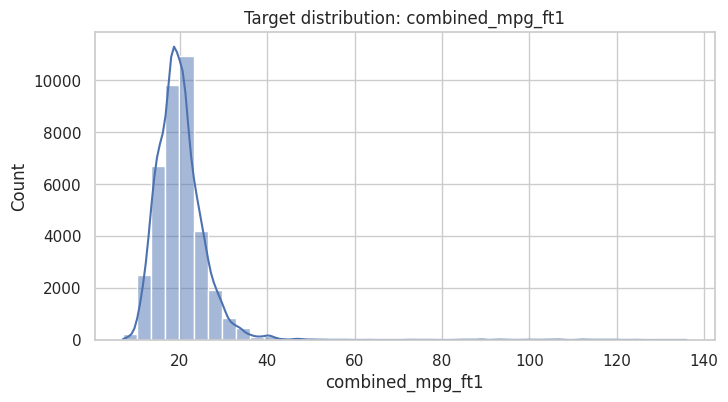

Top missing counts:


,0
supercharger,38113
fuel_type_2,38113
alternate_charger,38113
start_stop_technology,38113
electric_motor,38113
range_ft2,38113
manufacturer_code,38113
vehicle_charger,38113
gas_guzzler_tax,37149
alternative_fuel_technology,35066


In [6]:
# Target distribution and top missing columns
plt.figure(figsize=(8,4))
sns.histplot(df[TARGET].dropna(), kde=True, bins=40)
plt.title(f'Target distribution: {TARGET}')
plt.show()

print('Top missing counts:')
display(df.isna().sum().sort_values(ascending=False).head(40))

In [7]:
# Candidate features using your heuristics
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_candidates = [c for c in num_cols if c != TARGET and df[c].notna().mean() >= 0.30]

possible_cats = ["make", "model", "class", "drive", "transmission", "fuel_type", "vehicle_charger", "transmission_type"]
cat_candidates = [c for c in possible_cats if c in df.columns]

SELECT_FEATURES = (num_candidates[:8] + cat_candidates[:4])
print('Numeric candidate features (>=30% non-null):', num_candidates)
print('Categorical candidate features (present):', cat_candidates)
print('Selected features (initial):', SELECT_FEATURES)

# Build working DataFrame with only the selected features + target
work = df[[TARGET] + [c for c in SELECT_FEATURES if c in df.columns]].copy()

# Prepare a tiny helper DataFrame that contains only extra columns derive_features needs
extra_cols = [c for c in ['year', 'engine_descriptor'] if c in df.columns and c not in work.columns]
if extra_cols:
    extra_df = df[extra_cols].copy()
    # concat only the needed extra cols (no duplicate columns)
    work_with_extras = pd.concat([work, extra_df], axis=1)
else:
    work_with_extras = work.copy()

# Call derive_features on this safe, non-duplicated frame
work_with_extras = derive_features(work_with_extras, year_col='year')

# Now move any newly derived columns into 'work' to keep the original selected-feature set plus derived features
derived_cols = [c for c in ['vehicle_age', 'engine_displacement_l', 'cylinders', 'is_electric'] if c in work_with_extras.columns]
for c in derived_cols:
    work[c] = work_with_extras[c]

# Ensure vehicle_age is in SELECT_FEATURES for downstream modeling
if 'vehicle_age' in work.columns and 'vehicle_age' not in SELECT_FEATURES:
    SELECT_FEATURES.append('vehicle_age')

print('Final selected features used in work frame:', SELECT_FEATURES)
display(work.head(3))
work.to_csv(os.path.join(OUTDIR, 'work_cleaned.csv'), index=False)
print('Saved cleaned working CSV to', os.path.join(OUTDIR, 'work_cleaned.csv'))

Numeric candidate features (>=30% non-null): ['vehicle_id', 'year', 'engine_index', 'engine_cylinders', 'engine_displacement', 'city_mpg_ft1', 'unrounded_city_mpg_ft1', 'city_mpg_ft2', 'unrounded_city_mpg_ft2', 'city_gasoline_consumption_cd', 'city_electricity_consumption', 'city_utility_factor', 'highway_mpg_ft1', 'unrounded_highway_mpg_ft1', 'highway_mpg_ft2', 'unrounded_highway_mpg_ft2', 'highway_gasoline_consumption_cd', 'highway_electricity_consumption', 'highway_utility_factor', 'unadjusted_city_mpg_ft1', 'unadjusted_highway_mpg_ft1', 'unadjusted_city_mpg_ft2', 'unadjusted_highway_mpg_ft2', 'unrounded_combined_mpg_ft1', 'combined_mpg_ft2', 'unrounded_combined_mpg_ft2', 'combined_electricity_consumption', 'combined_gasoline_consumption_cd', 'combined_utility_factor', 'annual_fuel_cost_ft1', 'annual_fuel_cost_ft2', 'save_or_spend_5_year', 'annual_consumption_in_barrels_ft1', 'annual_consumption_in_barrels_ft2', 'tailpipe_co2_ft1', 'tailpipe_co2_in_grams_mile_ft1', 'tailpipe_co2_ft2

,combined_mpg_ft1,vehicle_id,year,engine_index,engine_cylinders,engine_displacement,city_mpg_ft1,unrounded_city_mpg_ft1,city_mpg_ft2,make,model,class,drive,vehicle_age,engine_displacement_l,cylinders,is_electric
0,20,26587,1984,9001,6.0,2.5,17,0.0,0,Alfa Romeo,GT V6 2.5,Minicompact Cars,NaN,41,NaN,NaN,False
1,20,27705,1984,9005,6.0,2.5,17,0.0,0,Alfa Romeo,GT V6 2.5,Minicompact Cars,NaN,41,NaN,NaN,False
2,21,26561,1984,9002,4.0,2.0,18,0.0,0,Alfa Romeo,Spider Veloce 2000,Two Seaters,NaN,41,NaN,NaN,False


Saved cleaned working CSV to artifacts/work_cleaned.csv


In [8]:
# Diagnostic: show duplicate columns after the concat that caused the error
tmp = pd.concat([df, df[[TARGET] + [c for c in SELECT_FEATURES if c in df.columns]].copy()], axis=1)
cols = pd.Series(tmp.columns)
dupes = cols[cols.duplicated()].unique().tolist()
print('Duplicated column labels in concat:', dupes)

Duplicated column labels in concat: ['combined_mpg_ft1', 'vehicle_id', 'year', 'engine_index', 'engine_cylinders', 'engine_displacement', 'city_mpg_ft1', 'unrounded_city_mpg_ft1', 'city_mpg_ft2', 'make', 'model', 'class', 'drive']


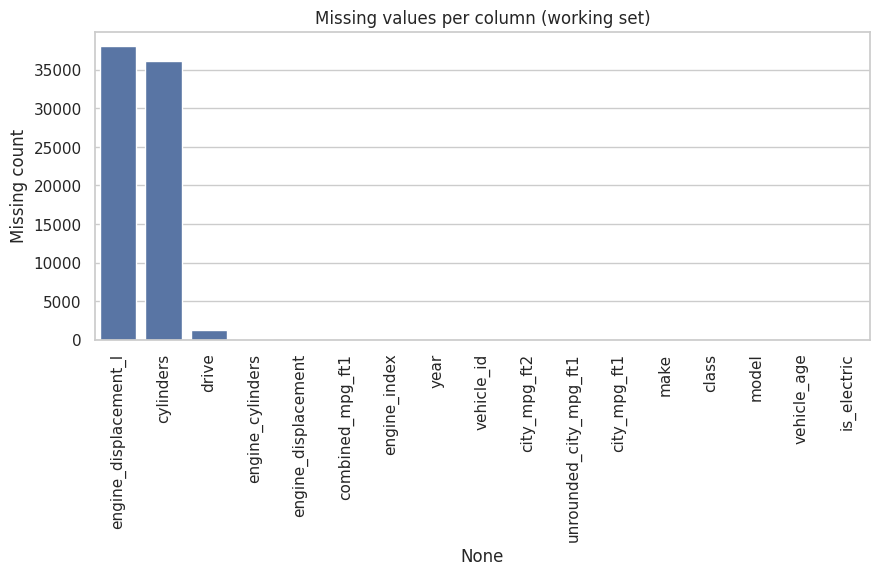

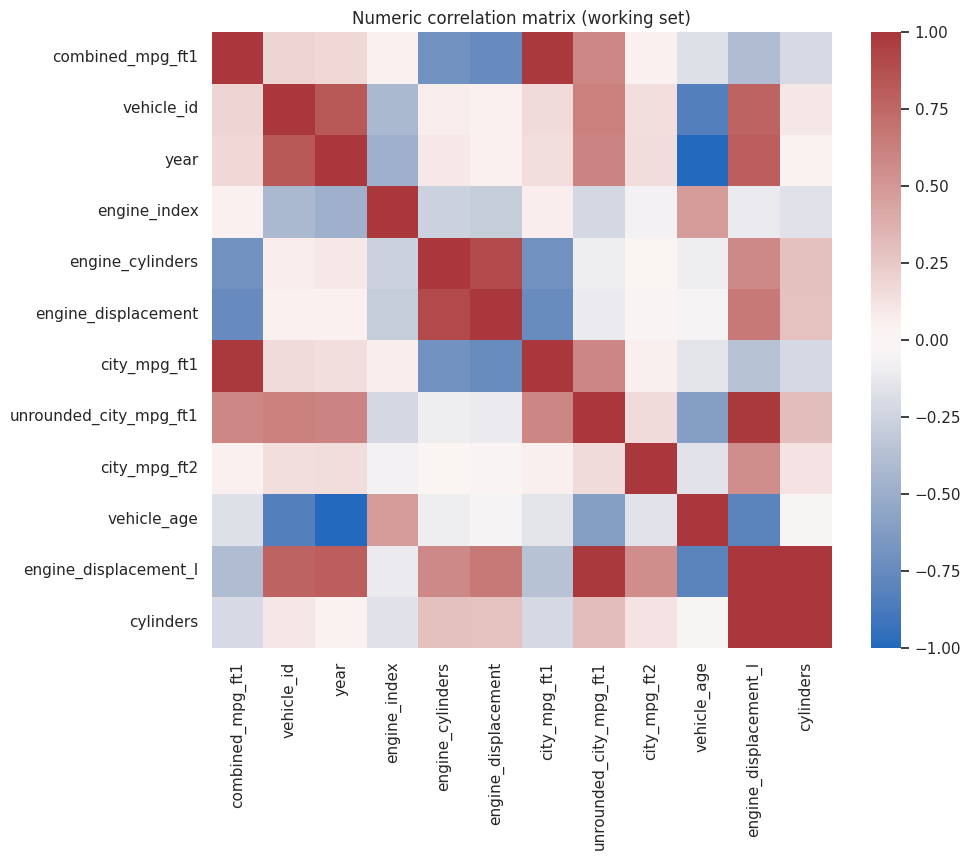

Top absolute correlations with target:


,combined_mpg_ft1
combined_mpg_ft1,1.000000
city_mpg_ft1,0.988213
engine_displacement,0.742872
engine_cylinders,0.697556
unrounded_city_mpg_ft1,0.582412
engine_displacement_l,0.402602
cylinders,0.208798
vehicle_id,0.188309
year,0.179658
vehicle_age,0.179658


In [9]:
plt.figure(figsize=(10,4))
missing_counts = work.isna().sum().sort_values(ascending=False)
sns.barplot(x=missing_counts.index, y=missing_counts.values)
plt.xticks(rotation=90)
plt.ylabel('Missing count')
plt.title('Missing values per column (working set)')
plt.show()

numeric_df = work.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 2:
    plt.figure(figsize=(10,8))
    sns.heatmap(numeric_df.corr(), cmap='vlag', center=0)
    plt.title('Numeric correlation matrix (working set)')
    plt.show()
    if TARGET in numeric_df.columns:
        print('Top absolute correlations with target:')
        display(numeric_df.corr()[TARGET].abs().sort_values(ascending=False).head(15))

In [10]:
# Drop rows with missing target and prepare X, y
df_model = work[work[TARGET].notna()].reset_index(drop=True)
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print('Numeric features:', num_features)
print('Categorical features:', cat_features)

Numeric features: ['vehicle_id', 'year', 'engine_index', 'engine_cylinders', 'engine_displacement', 'city_mpg_ft1', 'unrounded_city_mpg_ft1', 'city_mpg_ft2', 'vehicle_age', 'engine_displacement_l', 'cylinders']
Categorical features: ['make', 'model', 'class', 'drive']


In [11]:
ohe_sig = inspect.signature(OneHotEncoder).parameters
ohe_kwargs = {"handle_unknown": "ignore"}
if "sparse_output" in ohe_sig:
    ohe_kwargs["sparse_output"] = False
else:
    ohe_kwargs["sparse"] = False
print("OHE kwargs:", ohe_kwargs)

OHE kwargs: {'handle_unknown': 'ignore', 'sparse_output': False}


In [12]:
numeric_transformer = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())
categorical_transformer = make_pipeline(SimpleImputer(strategy='constant', fill_value='MISSING'), OneHotEncoder(**ohe_kwargs))
preprocessor = make_column_transformer((numeric_transformer, num_features), (categorical_transformer, cat_features))

rf_pipeline = make_pipeline(preprocessor, RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=2))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
rf_pipeline.fit(X_train, y_train)
preds = rf_pipeline.predict(X_test)
mae = mean_absolute_error(y_test, preds)
mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, preds)
print(f'Baseline RF -> MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}')

joblib.dump(rf_pipeline, os.path.join(OUTDIR, 'baseline_rf_pipeline.pkl'))
with open(os.path.join(OUTDIR, 'baseline_metrics.json'), 'w') as f:
    json.dump({'mae': float(mae), 'rmse': float(rmse), 'r2': float(r2)}, f)
print('Saved baseline pipeline and metrics to', OUTDIR)

Train shape: (30490, 16) Test shape: (7623, 16)
Baseline RF -> MAE: 0.291, RMSE: 0.495, R2: 0.995
Saved baseline pipeline and metrics to artifacts


In [13]:
HIGH_CARD_K = 50
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
for c in cat_cols:
    try:
        nunique = X[c].nunique()
    except Exception:
        nunique = 0
    if nunique > HIGH_CARD_K:
        print('Lumping column', c, 'from', nunique, '->', HIGH_CARD_K)
        X[c] = top_k_lump(X[c], k=HIGH_CARD_K)
        work[c] = top_k_lump(work[c], k=HIGH_CARD_K)

# recompute lists
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=['object','category']).columns.tolist()
print('Now numeric features:', len(num_features), 'categorical features:', len(cat_features))

Lumping column make from 133 -> 50
Lumping column model from 3748 -> 50
Now numeric features: 11 categorical features: 4


In [14]:
ohe_kwargs2 = {'handle_unknown': 'ignore'}
if 'sparse_output' in ohe_sig:
    ohe_kwargs2['sparse_output'] = True
else:
    ohe_kwargs2['sparse'] = True

numeric_transformer = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())
if len(cat_features) > 0:
    categorical_transformer = make_pipeline(SimpleImputer(strategy='constant', fill_value='MISSING'), OneHotEncoder(**ohe_kwargs2))
    preprocessor2 = make_column_transformer((numeric_transformer, num_features), (categorical_transformer, cat_features))
else:
    preprocessor2 = make_column_transformer((numeric_transformer, num_features))

if LGBMRegressor is None:
    print('LightGBM not installed; skipping LGBM CV. Install lightgbm to enable it.')
else:
    lgbm_pipeline = make_pipeline(preprocessor2, LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=RANDOM_STATE, n_jobs=N_JOBS))
    # choose CV strategy with groups if helpful
    groups = None
    use_groups = False
    if GROUP_COL and GROUP_COL in work.columns:
        groups = work.loc[df_model.index, GROUP_COL].fillna('MISSING')
        if groups.nunique() >= 5:
            cv = GroupKFold(n_splits=5)
            use_groups = True
            print('Using GroupKFold on', GROUP_COL)
        else:
            cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    else:
        cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    print('Running cross_validate for LGBM (may take a few minutes)...')
    if use_groups:
        scores = cross_validate(lgbm_pipeline, X, y, cv=cv, groups=groups, scoring=['neg_mean_absolute_error','r2'], n_jobs=N_JOBS)
    else:
        scores = cross_validate(lgbm_pipeline, X, y, cv=cv, scoring=['neg_mean_absolute_error','r2'], n_jobs=N_JOBS)

    print('MAE (neg) mean:', scores['test_neg_mean_absolute_error'].mean())
    print('R2 mean:', scores['test_r2'].mean())
    print('MAE per fold (pos):', -scores['test_neg_mean_absolute_error'])

    cv_summary = {
        'mae_mean': float((-scores['test_neg_mean_absolute_error']).mean()),
        'mae_std': float((-scores['test_neg_mean_absolute_error']).std()),
        'r2_mean': float(scores['test_r2'].mean()),
        'r2_std': float(scores['test_r2'].std())
    }
    with open(os.path.join(OUTDIR, 'lgbm_cv_summary.json'), 'w') as f:
        json.dump(cv_summary, f)
    print('Saved LGBM CV summary to', os.path.join(OUTDIR, 'lgbm_cv_summary.json'))

Running cross_validate for LGBM (may take a few minutes)...
MAE (neg) mean: -0.3788378966153071
R2 mean: 0.9941691698690651
MAE per fold (pos): [0.38191924 0.37815432 0.37708228 0.37897743 0.37805622]
Saved LGBM CV summary to artifacts/lgbm_cv_summary.json


In [15]:
if DO_TUNING:
    if optuna is None:
        raise ImportError("Optuna not installed; pip install optuna to enable tuning")
    if LGBMRegressor is None:
        raise ImportError("LightGBM not installed; pip install lightgbm to enable tuning")
    from sklearn.metrics import make_scorer
    def lgb_objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 2000, step=100),
            'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.3),
            'num_leaves': trial.suggest_int('num_leaves', 8, 512),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 200),
            'subsample': trial.suggest_float('subsample', 0.4, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
            'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-8, 10.0),
            'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-8, 10.0),
            'random_state': RANDOM_STATE,
            'n_jobs': N_JOBS
        }
        model = LGBMRegressor(**params)
        pipe = make_pipeline(preprocessor2, model)
        from sklearn.model_selection import cross_val_score
        scores = cross_val_score(pipe, X, y, cv=cv, groups=(groups if use_groups else None),
                                 scoring=make_scorer(mean_absolute_error, greater_is_better=False), n_jobs=1)
        return float(np.mean(scores))

    study = optuna.create_study(direction='minimize')
    study.optimize(lgb_objective, n_trials=TUNING_TRIALS)
    print('Best trial params:', study.best_trial.params)
    joblib.dump(study, os.path.join(OUTDIR, 'optuna_lgbm_study.pkl'))
    best = study.best_trial.params
    # build and fit final tuned model on full data
    lgb_final = make_pipeline(preprocessor2, LGBMRegressor(**{k: best[k] for k in best}, random_state=RANDOM_STATE, n_jobs=N_JOBS))
    lgb_final.fit(X, y)
    joblib.dump(lgb_final, os.path.join(OUTDIR, 'lgbm_pipeline_tuned.pkl'))
    print('Saved tuned LGBM pipeline to', os.path.join(OUTDIR, 'lgbm_pipeline_tuned.pkl'))
else:
    print("Skipping Optuna tuning (DO_TUNING=False)")

Skipping Optuna tuning (DO_TUNING=False)


In [16]:
if LGBMRegressor is not None:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
    lgbm_hold = make_pipeline(preprocessor2, LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=RANDOM_STATE, n_jobs=N_JOBS))
    lgbm_hold.fit(Xtr, ytr)
    preds_hold = lgbm_hold.predict(Xte)
    mae_hold = mean_absolute_error(yte, preds_hold)
    rmse_hold = mean_squared_error(yte, preds_hold) ** 0.5
    r2_hold = r2_score(yte, preds_hold)
    print(f'Holdout LGBM -> MAE: {mae_hold:.4f}, RMSE: {rmse_hold:.4f}, R2: {r2_hold:.4f}')
    joblib.dump(lgbm_hold, os.path.join(OUTDIR, 'lgbm_pipeline_holdout.pkl'))
    with open(os.path.join(OUTDIR, 'lgbm_holdout_metrics.json'), 'w') as f:
        json.dump({'mae': float(mae_hold), 'rmse': float(rmse_hold), 'r2': float(r2_hold)}, f)
    # save holdout predictions
    hold_df = Xte.copy()
    hold_df['y_true'] = yte
    hold_df['y_pred'] = preds_hold
    hold_df.to_csv(os.path.join(OUTDIR, 'lgbm_holdout_predictions.csv'), index=False)
    print('Saved holdout pipeline, metrics, and predictions to', OUTDIR)
else:
    print('LightGBM not available; skipped holdout training')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013048 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1318
[LightGBM] [Info] Number of data points in the train set: 30490, number of used features: 150
[LightGBM] [Info] Start training from score 20.194096
Holdout LGBM -> MAE: 0.3823, RMSE: 0.5363, R2: 0.9936
Saved holdout pipeline, metrics, and predictions to artifacts


In [17]:
if LGBMRegressor is not None:
    sample_n = min(2000, len(Xte))
    Xte_sample = Xte.sample(n=sample_n, random_state=RANDOM_STATE)
    yte_sample = yte.loc[Xte_sample.index]
    print('Computing permutation importance on', len(Xte_sample), 'rows...')
    r = permutation_importance(lgbm_hold, Xte_sample, yte_sample, n_repeats=10, random_state=RANDOM_STATE, n_jobs=N_JOBS)
    imp_df = pd.DataFrame({'feature': X.columns, 'importance_mean': r.importances_mean, 'importance_std': r.importances_std}).sort_values('importance_mean', ascending=False)
    display(imp_df.head(30))
    imp_df.to_csv(os.path.join(OUTDIR, 'permutation_importance.csv'), index=False)
    print('Saved permutation importance to', os.path.join(OUTDIR, 'permutation_importance.csv'))
else:
    print('Skipping permutation importance (LGBM missing)')

Computing permutation importance on 2000 rows...


,feature,importance_mean,importance_std
5,city_mpg_ft1,1.683190,0.027173
6,unrounded_city_mpg_ft1,0.006506,0.000255
4,engine_displacement,0.003936,0.000311
10,class,0.003049,0.000152
1,year,0.001833,0.000126
8,make,0.001548,0.000190
11,drive,0.001437,0.000067
2,engine_index,0.001089,0.000131
0,vehicle_id,0.000560,0.000082
3,engine_cylinders,0.000390,0.000036


Saved permutation importance to artifacts/permutation_importance.csv


In [18]:
if DO_SHAP and shap is not None and LGBMRegressor is not None:
    try:
        X_shap = Xte.sample(n=min(SHAP_SAMPLE_N, len(Xte)), random_state=RANDOM_STATE)
        model = lgbm_hold.steps[-1][1]  # raw LGBM model
        expl = shap.TreeExplainer(model)
        print('Computing SHAP values on', len(X_shap), 'rows...')
        # TreeExplainer accepts raw model and DataFrame; shap returns an Explanation object
        shap_values = expl(X_shap)
        joblib.dump(shap_values, os.path.join(OUTDIR, 'shap_values_sample.pkl'))
        print('Saved SHAP values (sample) to', os.path.join(OUTDIR, 'shap_values_sample.pkl'))
        # Show a summary plot (may open in notebook)
        try:
            shap.summary_plot(shap_values, X_shap, show=True)
        except Exception as e:
            print('Could not render SHAP summary plot:', e)
    except Exception as e:
        print('SHAP computation failed:', e)
else:
    print('Skipping SHAP (DO_SHAP=False or shap/lightgbm missing)')

Computing SHAP values on 500 rows...
SHAP computation failed: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: make: object, model: object, class: object, drive: object


In [19]:
GROUPS_TO_CHECK = ['make', 'model', 'class']
# Ensure hold_df is present
if 'hold_df' not in globals():
    print('Holdout predictions not found; run Cell 16 to generate holdout predictions first.')
else:
    for gcol in GROUPS_TO_CHECK:
        if gcol in work.columns:
            print('\nGroup:', gcol)
            grp_df = pd.DataFrame({'group': work.loc[hold_df.index, gcol].fillna('MISSING'), 'y_true': hold_df['y_true'].values, 'y_pred': hold_df['y_pred'].values})
            grp_stats = grp_df.groupby('group').apply(lambda g: pd.Series({'MAE': (g['y_true'] - g['y_pred']).abs().mean(), 'N': len(g)})).sort_values('MAE', ascending=False)
            display(grp_stats.head(20))
        else:
            print('Column', gcol, 'not in data')


Group: make


,MAE,N
group,,
Renault,0.625809,9.0
Lotus,0.544333,10.0
OTHER,0.504325,139.0
Plymouth,0.495010,108.0
Peugeot,0.471768,22.0
Maserati,0.462812,27.0
Kia,0.451276,106.0
Honda,0.428741,185.0
Dodge,0.427396,493.0



Group: model


,MAE,N
group,,
Grand Am,0.601617,11.0
Mirage,0.577665,21.0
B150/B250 Wagon 2WD,0.536408,10.0
Ranger Pickup 4WD,0.501212,24.0
Colt,0.484587,20.0
Sentra,0.480114,27.0
Escort,0.478298,23.0
Lancer,0.464811,27.0
Corolla,0.463869,23.0



Group: class


,MAE,N
group,,
Standard Pickup Trucks/2wd,0.515685,1.0
Small Station Wagons,0.454303,269.0
Midsize Station Wagons,0.440611,113.0
Minivan - 2WD,0.429685,68.0
Subcompact Cars,0.421895,1010.0
Compact Cars,0.416586,1081.0
Standard Pickup Trucks,0.415050,463.0
Small Pickup Trucks,0.401222,109.0
Special Purpose Vehicle 2WD,0.393455,121.0


In [20]:
def run_ablation(exclude_prefixes=None, exclude_cols=None, cv_splits=5):
    exclude_prefixes = exclude_prefixes or []
    exclude_cols = exclude_cols or []
    cols = X.columns.tolist()
    drop_cols = [c for c in cols if any(c.startswith(p) for p in exclude_prefixes) or c in exclude_cols]
    X2 = X.drop(columns=drop_cols)
    numf = X2.select_dtypes(include=[np.number]).columns.tolist()
    catf = X2.select_dtypes(include=['object','category']).columns.tolist()
    ohe_kwargs_local = ohe_kwargs2.copy() if 'ohe_kwargs2' in globals() else ohe_kwargs.copy()
    numeric_transformer = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())
    if len(catf) > 0:
        categorical_transformer = make_pipeline(SimpleImputer(strategy='constant', fill_value='MISSING'), OneHotEncoder(**ohe_kwargs_local))
        pre = make_column_transformer((numeric_transformer, numf), (categorical_transformer, catf))
    else:
        pre = make_column_transformer((numeric_transformer, numf))
    model = LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=RANDOM_STATE, n_jobs=1) if LGBMRegressor is not None else RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
    pipe = make_pipeline(pre, model)
    cv = KFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(pipe, X2, y, cv=cv, scoring=['neg_mean_absolute_error'], n_jobs=1)
    return {'exclude': {'prefixes': exclude_prefixes, 'cols': exclude_cols}, 'mae_mean': float((-scores['test_neg_mean_absolute_error']).mean()), 'mae_std': float((-scores['test_neg_mean_absolute_error']).std())}

ablation_results = []
ablation_results.append(run_ablation(exclude_prefixes=['vehicle_age']))
ablation_results.append(run_ablation(exclude_prefixes=['engine_']))
ablation_results.append(run_ablation(exclude_cols=cat_cols[:2] if len(cat_cols) >= 2 else []))
pd.DataFrame(ablation_results)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013429 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1283
[LightGBM] [Info] Number of data points in the train set: 30490, number of used features: 149
[LightGBM] [Info] Start training from score 20.194096
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018650 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1285
[LightGBM] [Info] Number of data points in the train set: 30490, number of used features: 149
[LightGBM] [Info] Start training from score 20.229911
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024033 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

,exclude,mae_mean,mae_std
0,"{'prefixes': ['vehicle_age'], 'cols': []}",0.401854,0.001258
1,"{'prefixes': ['engine_'], 'cols': []}",0.419572,0.001311
2,"{'prefixes': [], 'cols': ['make', 'model']}",0.407391,0.002963


In [21]:
# Choose final pipeline: prefer the holdout LGBM if available, else baseline RF
final_pipeline = None
final_metrics = {}
if 'lgbm_hold' in globals():
    final_pipeline = lgbm_hold
    final_metrics = {'mae': mae_hold, 'rmse': rmse_hold, 'r2': r2_hold}
else:
    final_pipeline = rf_pipeline
    final_metrics = {'mae': mae, 'rmse': rmse, 'r2': r2}

joblib.dump(final_pipeline, os.path.join(OUTDIR, 'final_pipeline.pkl'))
with open(os.path.join(OUTDIR, 'final_metrics.json'), 'w') as f:
    json.dump({k: float(v) for k, v in final_metrics.items()}, f)
print('Saved final pipeline and metrics to', OUTDIR)

Saved final pipeline and metrics to artifacts


In [22]:
report_md = f"""
# Fuel Efficiency Modeling — Report

## Executive summary
- Data rows: {len(df):,}
- Target: {TARGET}
- Final model chosen: {'LightGBM (holdout)' if 'lgbm_hold' in globals() else 'RandomForest baseline'}
- Final metrics (holdout/CV) - MAE: {final_metrics.get('mae', 'NA'):.4f}, RMSE: {final_metrics.get('rmse', 'NA'):.4f}, R2: {final_metrics.get('r2', 'NA'):.4f}

## Data & preprocessing
- Cleaned CSV saved at artifacts/work_cleaned.csv

## Modeling notes
- Baseline: RandomForest
- Advanced: LightGBM (CV results saved)

## Interpretability artifacts
- Permutation importances: artifacts/permutation_importance.csv
- SHAP (sample): artifacts/shap_values_sample.pkl (if generated)

## Next steps
- Expand feature engineering (text parsing of model/make, more derived features)
- Run Optuna tuning for LightGBM/XGBoost if compute budget allows
"""

with open(os.path.join(OUTDIR, 'report.md'), 'w') as f:
    f.write(report_md)
print('Saved report to', os.path.join(OUTDIR, 'report.md'))

Saved report to artifacts/report.md


In [23]:
!ls -lh artifacts

total 84M
-rw-r--r-- 1 root root   81 Dec  5 20:59 baseline_metrics.json
-rw-r--r-- 1 root root  74M Dec  5 20:59 baseline_rf_pipeline.pkl
-rw-r--r-- 1 root root   81 Dec  5 21:01 final_metrics.json
-rw-r--r-- 1 root root 2.9M Dec  5 21:01 final_pipeline.pkl
-rw-r--r-- 1 root root  129 Dec  5 21:00 lgbm_cv_summary.json
-rw-r--r-- 1 root root   81 Dec  5 21:00 lgbm_holdout_metrics.json
-rw-r--r-- 1 root root 866K Dec  5 21:00 lgbm_holdout_predictions.csv
-rw-r--r-- 1 root root 2.9M Dec  5 21:00 lgbm_pipeline_holdout.pkl
-rw-r--r-- 1 root root  829 Dec  5 21:01 permutation_importance.csv
-rw-r--r-- 1 root root  699 Dec  5 21:01 report.md
-rw-r--r-- 1 root root 3.8M Dec  5 20:53 work_cleaned.csv


In [24]:
df_clean = pd.read_csv('artifacts/work_cleaned.csv')
df_clean.shape, df_clean.columns.tolist()
display(df_clean.head())

,combined_mpg_ft1,vehicle_id,year,engine_index,engine_cylinders,engine_displacement,city_mpg_ft1,unrounded_city_mpg_ft1,city_mpg_ft2,make,model,class,drive,vehicle_age,engine_displacement_l,cylinders,is_electric
0,20,26587,1984,9001,6.0,2.5,17,0.0,0,Alfa Romeo,GT V6 2.5,Minicompact Cars,NaN,41,NaN,NaN,False
1,20,27705,1984,9005,6.0,2.5,17,0.0,0,Alfa Romeo,GT V6 2.5,Minicompact Cars,NaN,41,NaN,NaN,False
2,21,26561,1984,9002,4.0,2.0,18,0.0,0,Alfa Romeo,Spider Veloce 2000,Two Seaters,NaN,41,NaN,NaN,False
3,21,27681,1984,9006,4.0,2.0,18,0.0,0,Alfa Romeo,Spider Veloce 2000,Two Seaters,NaN,41,NaN,NaN,False
4,17,27550,1984,1830,4.0,2.5,18,0.0,0,AM General,DJ Po Vehicle 2WD,Special Purpose Vehicle 2WD,2-Wheel Drive,41,NaN,NaN,False


In [25]:
for fname in ['baseline_metrics.json','lgbm_cv_summary.json','lgbm_holdout_metrics.json','final_metrics.json']:
    path = f'artifacts/{fname}'
    try:
        print(fname, ':')
        print(json.load(open(path)))
    except FileNotFoundError:
        print(fname, 'not found')
    print('---')

baseline_metrics.json :
{'mae': 0.2914403778040142, 'rmse': 0.4947614199313635, 'r2': 0.9945686668056042}
---
lgbm_cv_summary.json :
{'mae_mean': 0.3788378966153071, 'mae_std': 0.001653763802644226, 'r2_mean': 0.9941691698690651, 'r2_std': 0.0004988576730830046}
---
lgbm_holdout_metrics.json :
{'mae': 0.3823356729607204, 'rmse': 0.5363148216135873, 'r2': 0.9936180354091245}
---
final_metrics.json :
{'mae': 0.3823356729607204, 'rmse': 0.5363148216135873, 'r2': 0.9936180354091245}
---


,vehicle_id,year,engine_index,engine_cylinders,engine_displacement,city_mpg_ft1,unrounded_city_mpg_ft1,city_mpg_ft2,make,model,class,drive,vehicle_age,engine_displacement_l,cylinders,is_electric,y_true,y_pred
0,27877,1984,59045,4.0,1.7,22,0.0000,0,Volkswagen,Jetta,Subcompact Cars,NaN,41,NaN,NaN,False,25,24.470674
1,2748,1986,4801,4.0,2.5,20,0.0000,0,Chevrolet,OTHER,Special Purpose Vehicle 2WD,Rear-Wheel Drive,39,NaN,NaN,False,22,21.859365
2,26026,2009,0,4.0,2.5,19,0.0000,0,Subaru,OTHER,Small Station Wagons,4-Wheel or All-Wheel Drive,16,NaN,NaN,False,21,21.408073
3,30899,2011,85,6.0,3.5,19,18.8536,0,Toyota,OTHER,Sport Utility Vehicle - 2WD,Front-Wheel Drive,14,NaN,NaN,False,21,21.239241
4,13150,1996,3723,6.0,4.0,14,0.0000,0,Ford,OTHER,Special Purpose Vehicles,Rear-Wheel Drive,29,NaN,NaN,False,16,15.518997


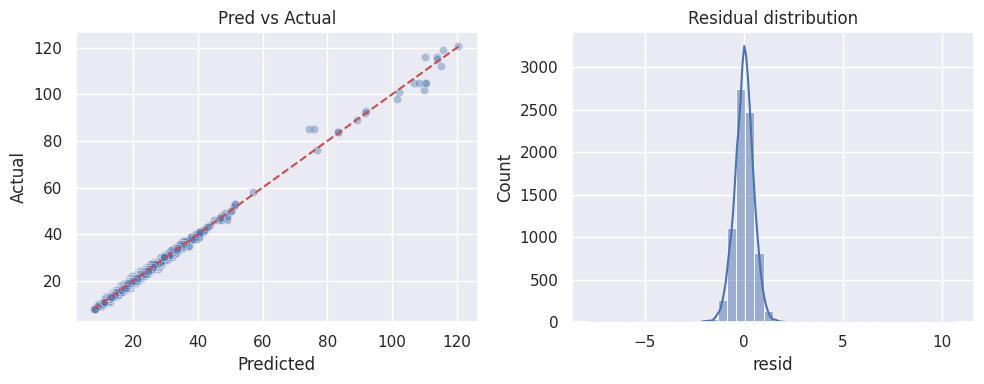

In [26]:
sns.set()
hold_path = 'artifacts/lgbm_holdout_predictions.csv'
if os.path.exists(hold_path):
    hold = pd.read_csv(hold_path)
    display(hold.head())
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.scatterplot(x='y_pred', y='y_true', data=hold, alpha=0.4)
    mn,mx = hold[['y_pred','y_true']].min().min(), hold[['y_pred','y_true']].max().max()
    plt.plot([mn,mx],[mn,mx], 'r--')
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Pred vs Actual')

    plt.subplot(1,2,2)
    hold['resid'] = hold['y_true'] - hold['y_pred']
    sns.histplot(hold['resid'], bins=40, kde=True)
    plt.title('Residual distribution')
    plt.tight_layout()
    plt.show()
else:
    print('Holdout predictions not found at', hold_path)

In [27]:
imp_path = 'artifacts/permutation_importance.csv'
if os.path.exists(imp_path):
    imp = pd.read_csv(imp_path)
    display(imp.head(30))
else:
    print('No permutation_importance.csv found')

,feature,importance_mean,importance_std
0,city_mpg_ft1,1.683190,0.027173
1,unrounded_city_mpg_ft1,0.006506,0.000255
2,engine_displacement,0.003936,0.000311
3,class,0.003049,0.000152
4,year,0.001833,0.000126
5,make,0.001548,0.000190
6,drive,0.001437,0.000067
7,engine_index,0.001089,0.000131
8,vehicle_id,0.000560,0.000082
9,engine_cylinders,0.000390,0.000036


In [28]:
if os.path.exists(hold_path):
    top = hold.assign(abs_err=hold['resid'].abs()).sort_values('abs_err', ascending=False).head(15)
    display(top)
    # If you want to inspect features for the worst rows, load Xte from notebook or the saved CSV
else:
    print('No holdout predictions to inspect worst errors')

,vehicle_id,year,engine_index,engine_cylinders,engine_displacement,city_mpg_ft1,unrounded_city_mpg_ft1,city_mpg_ft2,make,model,class,drive,vehicle_age,engine_displacement_l,cylinders,is_electric,y_true,y_pred,resid,abs_err
2943,16423,2000,0,NaN,NaN,81,0.0000,0,Nissan,OTHER,Midsize Station Wagons,NaN,25,NaN,NaN,False,85,74.301755,10.698245,10.698245
4588,30968,1999,0,NaN,NaN,79,0.0000,0,GMC,OTHER,Two Seaters,NaN,26,NaN,NaN,False,85,75.867224,9.132776,9.132776
345,32276,2011,100,NaN,NaN,107,106.7330,0,BMW,OTHER,Subcompact Cars,Rear-Wheel Drive,14,NaN,NaN,False,102,109.791658,-7.791658,7.791658
1442,34392,2014,339,NaN,NaN,122,122.4000,0,OTHER,OTHER,Minicompact Cars,Front-Wheel Drive,11,NaN,NaN,False,116,110.382559,5.617441,5.617441
6428,35601,2015,34,NaN,NaN,120,119.6000,0,Kia,OTHER,Small Station Wagons,Front-Wheel Drive,10,NaN,NaN,False,105,110.405424,-5.405424,5.405424
2359,36553,2016,37,NaN,NaN,120,119.6000,0,Kia,OTHER,Small Station Wagons,Front-Wheel Drive,9,NaN,NaN,False,105,110.210378,-5.210378,5.210378
4296,37421,2016,31,NaN,NaN,97,97.4898,0,OTHER,OTHER,Large Cars,Rear-Wheel Drive,9,NaN,NaN,False,98,101.422864,-3.422864,3.422864
5043,36978,2016,57,NaN,NaN,110,110.0400,0,Ford,OTHER,Compact Cars,Front-Wheel Drive,9,NaN,NaN,False,105,108.354445,-3.354445,3.354445
620,38187,2017,293,NaN,NaN,128,127.5400,0,Chevrolet,OTHER,Small Station Wagons,Front-Wheel Drive,8,NaN,NaN,False,119,115.923677,3.076323,3.076323
3693,33358,2013,141,NaN,NaN,126,126.3678,0,Mitsubishi,OTHER,Subcompact Cars,Rear-Wheel Drive,12,NaN,NaN,False,112,115.042468,-3.042468,3.042468


In [29]:
shap_path = 'artifacts/shap_values_sample.pkl'
if os.path.exists(shap_path):
    shap_v = joblib.load(shap_path)
    print(type(shap_v))
    # If shap.Explanation: you can do a quick summary_plot if shap is installed in the runtime
    try:
        import shap, matplotlib.pyplot as plt
        shap.summary_plot(shap_v, plot_type='bar', show=True)
    except Exception as e:
        print('SHAP plotting failed:', e)
else:
    print('No SHAP artifact found')

No SHAP artifact found


In [30]:
opt_path = 'artifacts/optuna_lgbm_study.pkl'
if os.path.exists(opt_path):
    study = joblib.load(opt_path)  # or optuna.load_study if saved differently
    print('Best params:', study.best_trial.params)
else:
    print('No optuna study found')

No optuna study found


In [31]:
# Diagnostic A: correlations and equality checks vs target

target = 'combined_mpg_ft1'
X = pd.read_csv('artifacts/work_cleaned.csv')  # or use df_clean from your session
cols = X.columns.tolist()

# numeric correlations
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target]
print('Numeric columns:', num_cols)

corrs = X[[target] + num_cols].corr()[target].abs().sort_values(ascending=False)
print('\nAbsolute Pearson correlations with target (top 15):\n', corrs.head(15))

# exact/close-equality detection for suspicious names
suspects = ['city_mpg_ft1','unrounded_city_mpg_ft1','city_mpg_ft2','combined_mpg','mpg']
for s in suspects:
    if s in X.columns:
        both = X[[s, target]].dropna()
        eq_count = (np.isclose(both[s].astype(float), both[target].astype(float))).sum()
        print(f"{s}: non-missing {len(both)}, close-equal rows: {eq_count} ({eq_count/len(both):.2%})")

Numeric columns: ['vehicle_id', 'year', 'engine_index', 'engine_cylinders', 'engine_displacement', 'city_mpg_ft1', 'unrounded_city_mpg_ft1', 'city_mpg_ft2', 'vehicle_age', 'engine_displacement_l', 'cylinders']

Absolute Pearson correlations with target (top 15):
 combined_mpg_ft1          1.000000
city_mpg_ft1              0.988213
engine_displacement       0.742872
engine_cylinders          0.697556
unrounded_city_mpg_ft1    0.582412
engine_displacement_l     0.402602
cylinders                 0.208798
vehicle_id                0.188309
year                      0.179658
vehicle_age               0.179658
city_mpg_ft2              0.051881
engine_index              0.049768
Name: combined_mpg_ft1, dtype: float64
city_mpg_ft1: non-missing 38113, close-equal rows: 489 (1.28%)
unrounded_city_mpg_ft1: non-missing 38113, close-equal rows: 6 (0.02%)
city_mpg_ft2: non-missing 38113, close-equal rows: 0 (0.00%)


In [32]:
# Diagnostic B: show permutation importance top 20 and worst errors from holdout
imp_path = 'artifacts/permutation_importance.csv'
if os.path.exists(imp_path):
    imp = pd.read_csv(imp_path).sort_values('importance_mean', ascending=False)
    display(imp.head(20))
else:
    print('No permutation_importance.csv found')

hold_path = 'artifacts/lgbm_holdout_predictions.csv'
if os.path.exists(hold_path):
    hold = pd.read_csv(hold_path)
    hold['abs_err'] = (hold['y_true'] - hold['y_pred']).abs()
    display(hold.sort_values('abs_err', ascending=False).head(15))
else:
    print('No holdout predictions found')

,feature,importance_mean,importance_std
0,city_mpg_ft1,1.683190,0.027173
1,unrounded_city_mpg_ft1,0.006506,0.000255
2,engine_displacement,0.003936,0.000311
3,class,0.003049,0.000152
4,year,0.001833,0.000126
5,make,0.001548,0.000190
6,drive,0.001437,0.000067
7,engine_index,0.001089,0.000131
8,vehicle_id,0.000560,0.000082
9,engine_cylinders,0.000390,0.000036


,vehicle_id,year,engine_index,engine_cylinders,engine_displacement,city_mpg_ft1,unrounded_city_mpg_ft1,city_mpg_ft2,make,model,class,drive,vehicle_age,engine_displacement_l,cylinders,is_electric,y_true,y_pred,abs_err
2943,16423,2000,0,NaN,NaN,81,0.0000,0,Nissan,OTHER,Midsize Station Wagons,NaN,25,NaN,NaN,False,85,74.301755,10.698245
4588,30968,1999,0,NaN,NaN,79,0.0000,0,GMC,OTHER,Two Seaters,NaN,26,NaN,NaN,False,85,75.867224,9.132776
345,32276,2011,100,NaN,NaN,107,106.7330,0,BMW,OTHER,Subcompact Cars,Rear-Wheel Drive,14,NaN,NaN,False,102,109.791658,7.791658
1442,34392,2014,339,NaN,NaN,122,122.4000,0,OTHER,OTHER,Minicompact Cars,Front-Wheel Drive,11,NaN,NaN,False,116,110.382559,5.617441
6428,35601,2015,34,NaN,NaN,120,119.6000,0,Kia,OTHER,Small Station Wagons,Front-Wheel Drive,10,NaN,NaN,False,105,110.405424,5.405424
2359,36553,2016,37,NaN,NaN,120,119.6000,0,Kia,OTHER,Small Station Wagons,Front-Wheel Drive,9,NaN,NaN,False,105,110.210378,5.210378
4296,37421,2016,31,NaN,NaN,97,97.4898,0,OTHER,OTHER,Large Cars,Rear-Wheel Drive,9,NaN,NaN,False,98,101.422864,3.422864
5043,36978,2016,57,NaN,NaN,110,110.0400,0,Ford,OTHER,Compact Cars,Front-Wheel Drive,9,NaN,NaN,False,105,108.354445,3.354445
620,38187,2017,293,NaN,NaN,128,127.5400,0,Chevrolet,OTHER,Small Station Wagons,Front-Wheel Drive,8,NaN,NaN,False,119,115.923677,3.076323
3693,33358,2013,141,NaN,NaN,126,126.3678,0,Mitsubishi,OTHER,Subcompact Cars,Rear-Wheel Drive,12,NaN,NaN,False,112,115.042468,3.042468


In [33]:
# Diagnostic C: group-level MAE for top groups (e.g., make, class)
work = pd.read_csv('artifacts/work_cleaned.csv')
hold = pd.read_csv('artifacts/lgbm_holdout_predictions.csv') if os.path.exists('artifacts/lgbm_holdout_predictions.csv') else None

groups = ['make','class','model']
if hold is None:
    print('Holdout predictions not available; run holdout training cell then re-run diagnostics.')
else:
    for g in groups:
        if g in work.columns:
            grp = pd.DataFrame({
                'group': work.loc[hold.index, g].fillna('MISSING'),
                'y_true': hold['y_true'].values, 'y_pred': hold['y_pred'].values
            })
            stats = grp.groupby('group').apply(lambda g: pd.Series({'MAE': (g['y_true'] - g['y_pred']).abs().mean(), 'N':len(g)})).sort_values('MAE', ascending=False)
            print(f'Group MAE top 10 for {g}:')
            display(stats.head(10))
        else:
            print(f'Column {g} not in dataset')

Group MAE top 10 for make:


,MAE,N
group,,
Excalibur Autos,0.901046,1.0
"JBA Motorcars, Inc.",0.726400,1.0
Volga Associated Automobile,0.725683,1.0
S and S Coach Company E.p. Dutton,0.721966,1.0
"E. P. Dutton, Inc.",0.606363,1.0
Acura,0.594657,18.0
ASC Incorporated,0.585044,1.0
Bitter Gmbh and Co. Kg,0.551130,5.0
CCC Engineering,0.535713,2.0


Group MAE top 10 for class:


,MAE,N
group,,
Standard Pickup Trucks 4WD,0.500381,103.0
Small Station Wagons,0.418275,386.0
Special Purpose Vehicle 4WD,0.413543,189.0
Special Purpose Vehicle 2WD,0.410620,328.0
Standard Pickup Trucks 2WD,0.410532,144.0
Vans,0.391774,562.0
Large Cars,0.383786,195.0
"Vans, Cargo Type",0.383204,80.0
Midsize-Large Station Wagons,0.382174,290.0


Group MAE top 10 for model:


,MAE,N
group,,
Custom Cruiser Wagon,1.172616,6.0
300TE,1.117885,1.0
Fleetwood Brougham,1.089891,1.0
Firenza Cruiser,0.945733,14.0
Sprint ER,0.943994,2.0
80/90 quattro,0.918318,2.0
300SDL,0.910294,2.0
V10 (K10) Suburban 4WD,0.904133,4.0
Phaeton,0.901046,1.0


In [34]:
# Drop suspected leakage/id columns and prepare X2, y2
drop_leak = ['city_mpg_ft1', 'unrounded_city_mpg_ft1', 'city_mpg_ft2', 'vehicle_id']
# keep only columns present in X
drop_leak = [c for c in drop_leak if c in X.columns]
print("Dropping columns from modeling:", drop_leak)

# New modeling frame
X2 = X.drop(columns=drop_leak, errors='ignore').copy()
y2 = y.copy()

# recompute numeric/categorical lists
num_features2 = X2.select_dtypes(include=[np.number]).columns.tolist()
cat_features2 = X2.select_dtypes(include=['object','category']).columns.tolist()
print("Numeric features (count):", len(num_features2), "Categorical features (count):", len(cat_features2))

Dropping columns from modeling: ['city_mpg_ft1', 'unrounded_city_mpg_ft1', 'city_mpg_ft2', 'vehicle_id']
Numeric features (count): 8 Categorical features (count): 4


In [35]:
# Correlations after dropping leak columns (use corrwith -> returns Series)
df_check = pd.concat([X2, y2], axis=1)

# make sure we reference the target column name (fallback to TARGET if y2 has no name)
target_name = y2.name if getattr(y2, "name", None) else TARGET

# use corrwith so we always get a Series
num_cols = df_check.select_dtypes(include=[np.number]).columns.tolist()
# exclude the target itself
if target_name in num_cols:
    num_cols = [c for c in num_cols if c != target_name]

corrs = df_check[num_cols].corrwith(df_check[target_name]).abs().sort_values(ascending=False)
print("Top numeric correlations with target after drop:")
display(corrs.head(15))

Top numeric correlations with target after drop:


,0
combined_mpg_ft1,NaN
cylinders,NaN
engine_cylinders,NaN
engine_displacement,NaN
engine_displacement_l,NaN
engine_index,NaN
vehicle_age,NaN
year,NaN


In [36]:
# Baseline RandomForest on X2 (holdout)

# OHE kwargs compatibility
ohe_sig = inspect.signature(OneHotEncoder).parameters
ohe_k = {"handle_unknown":"ignore"}
if "sparse_output" in ohe_sig:
    ohe_k["sparse_output"] = False
else:
    ohe_k["sparse"] = False

numeric_transformer = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())
categorical_transformer = make_pipeline(SimpleImputer(strategy='constant', fill_value='MISSING'), OneHotEncoder(**ohe_k))
preproc2 = make_column_transformer((numeric_transformer, num_features2), (categorical_transformer, cat_features2), remainder='drop')

rf2 = make_pipeline(preproc2, RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=2))

X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.2, random_state=RANDOM_STATE)
rf2.fit(X2_tr, y2_tr)
pred_rf2 = rf2.predict(X2_te)
mae_rf2 = mean_absolute_error(y2_te, pred_rf2)
rmse_rf2 = mean_squared_error(y2_te, pred_rf2)**0.5
r2_rf2 = r2_score(y2_te, pred_rf2)
print(f"RF (no-leak) holdout -> MAE: {mae_rf2:.4f}, RMSE: {rmse_rf2:.4f}, R2: {r2_rf2:.4f}")

# Save
joblib.dump(rf2, os.path.join(OUTDIR, 'baseline_rf_no_leak_pipeline.pkl'))
with open(os.path.join(OUTDIR, 'baseline_no_leak_metrics.json'),'w') as f:
    json.dump({'mae':float(mae_rf2),'rmse':float(rmse_rf2),'r2':float(r2_rf2)}, f)
print("Saved RF no-leak pipeline and metrics.")

RF (no-leak) holdout -> MAE: 0.0016, RMSE: 0.0466, R2: 1.0000
Saved RF no-leak pipeline and metrics.


In [37]:
# LightGBM CV and holdout (no-leak)
if LGBMRegressor is None:
    print("LightGBM not installed; install lightgbm to run this cell.")
else:
    from sklearn.model_selection import KFold, GroupKFold, cross_validate
    lgbm_no_leak = make_pipeline(preproc2, LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=RANDOM_STATE, n_jobs=N_JOBS))
    # Choose CV as before (respect GROUP_COL if present)
    groups2 = None
    use_groups2 = False
    if GROUP_COL and GROUP_COL in work.columns:
        groups2 = work.loc[df_model.index, GROUP_COL].fillna('MISSING')
        if groups2.nunique() >= 5:
            cv2 = GroupKFold(n_splits=5)
            use_groups2 = True
    else:
        cv2 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    print("Running CV for LGBM (no-leak)...")
    if use_groups2:
        scores2 = cross_validate(lgbm_no_leak, X2, y2, cv=cv2, groups=groups2, scoring=['neg_mean_absolute_error','r2'], n_jobs=N_JOBS)
    else:
        scores2 = cross_validate(lgbm_no_leak, X2, y2, cv=cv2, scoring=['neg_mean_absolute_error','r2'], n_jobs=N_JOBS)

    print("CV MAE mean:", (-scores2['test_neg_mean_absolute_error']).mean(), "R2 mean:", scores2['test_r2'].mean())

    # Holdout fit+eval
    X2tr, X2te, y2tr, y2te = train_test_split(X2, y2, test_size=0.2, random_state=RANDOM_STATE)
    lgbm_no_leak.fit(X2tr, y2tr)
    preds_lgb2 = lgbm_no_leak.predict(X2te)
    mae_lgb2 = mean_absolute_error(y2te, preds_lgb2)
    rmse_lgb2 = mean_squared_error(y2te, preds_lgb2)**0.5
    r2_lgb2 = r2_score(y2te, preds_lgb2)
    print(f"LGBM (no-leak) holdout -> MAE: {mae_lgb2:.4f}, RMSE: {rmse_lgb2:.4f}, R2: {r2_lgb2:.4f}")

    joblib.dump(lgbm_no_leak, os.path.join(OUTDIR, 'lgbm_no_leak_pipeline.pkl'))
    with open(os.path.join(OUTDIR, 'lgbm_no_leak_metrics.json'),'w') as f:
        json.dump({'mae':float(mae_lgb2),'rmse':float(rmse_lgb2),'r2':float(r2_lgb2)}, f)
    # save holdout preds for later diagnostics
    hold_no_leak = X2te.copy()
    hold_no_leak['y_true'] = y2te.values
    hold_no_leak['y_pred'] = preds_lgb2
    hold_no_leak.to_csv(os.path.join(OUTDIR, 'lgbm_no_leak_holdout_predictions.csv'), index=False)
    print("Saved LGBM no-leak pipeline, metrics and holdout predictions.")

Running CV for LGBM (no-leak)...
CV MAE mean: 0.005505455001483154 R2 mean: 0.9996092411778765
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009614 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1465
[LightGBM] [Info] Number of data points in the train set: 30490, number of used features: 489
[LightGBM] [Info] Start training from score 20.194096
LGBM (no-leak) holdout -> MAE: 0.0049, RMSE: 0.0928, R2: 0.9998
Saved LGBM no-leak pipeline, metrics and holdout predictions.


In [38]:
# Permutation importance on holdout (no-leak) and show worst errors
if LGBMRegressor is not None:
    sample_n2 = min(2000, len(X2te))
    X2te_sample = X2te.sample(n=sample_n2, random_state=RANDOM_STATE)
    y2te_sample = y2te.loc[X2te_sample.index]
    print('Computing permutation importance on', len(X2te_sample),'rows (no-leak)...')
    r2p = permutation_importance(lgbm_no_leak, X2te_sample, y2te_sample, n_repeats=10, random_state=RANDOM_STATE, n_jobs=N_JOBS)
    imp2 = pd.DataFrame({'feature': X2.columns, 'importance_mean': r2p.importances_mean, 'importance_std': r2p.importances_std}).sort_values('importance_mean', ascending=False)
    display(imp2.head(30))
    imp2.to_csv(os.path.join(OUTDIR, 'permutation_importance_no_leak.csv'), index=False)
    print('Saved permutation importance (no-leak) to', os.path.join(OUTDIR, 'permutation_importance_no_leak.csv'))
    # Worst errors
    hold_no_leak['abs_err'] = (hold_no_leak['y_true'] - hold_no_leak['y_pred']).abs()
    display(hold_no_leak.sort_values('abs_err', ascending=False).head(20))
else:
    print("No LightGBM installed; skip permutation importance cell.")

Computing permutation importance on 2000 rows (no-leak)...


,feature,importance_mean,importance_std
0,combined_mpg_ft1,2.001376e+00,3.254596e-02
5,make,1.137398e-04,1.909907e-04
2,engine_index,6.946255e-05,7.282189e-05
8,drive,4.005240e-06,1.640062e-06
4,engine_displacement,1.154436e-06,1.518360e-07
3,engine_cylinders,7.002819e-07,3.253012e-07
1,year,5.164505e-07,2.657937e-06
6,model,3.044906e-07,6.485257e-07
11,cylinders,4.523559e-12,5.198701e-11
10,engine_displacement_l,0.000000e+00,0.000000e+00


Saved permutation importance (no-leak) to artifacts/permutation_importance_no_leak.csv


,combined_mpg_ft1,year,engine_index,engine_cylinders,engine_displacement,make,model,class,drive,vehicle_age,engine_displacement_l,cylinders,is_electric,y_true,y_pred,abs_err
29847,102,2011,100,NaN,NaN,BMW,Active E,Subcompact Cars,Rear-Wheel Drive,14,NaN,NaN,False,102,106.092921,4.092921
32998,121,2013,21,NaN,NaN,Scion,iQ EV,Minicompact Cars,Front-Wheel Drive,12,NaN,NaN,False,121,117.527745,3.472255
37097,119,2017,293,NaN,NaN,Chevrolet,Bolt,Small Station Wagons,Front-Wheel Drive,8,NaN,NaN,False,119,115.850099,3.149901
36073,105,2016,57,NaN,NaN,Ford,Focus Electric,Compact Cars,Front-Wheel Drive,9,NaN,NaN,False,105,107.603350,2.603350
32870,112,2013,141,NaN,NaN,Mitsubishi,i-MiEV,Subcompact Cars,Rear-Wheel Drive,12,NaN,NaN,False,112,114.465852,2.465852
33530,116,2014,339,NaN,NaN,Fiat,500e,Minicompact Cars,Front-Wheel Drive,11,NaN,NaN,False,116,113.839591,2.160409
34814,105,2015,116,NaN,NaN,Ford,Focus Electric,Compact Cars,Front-Wheel Drive,10,NaN,NaN,False,105,106.526267,1.526267
36762,101,2016,6,NaN,NaN,Tesla,Model S AWD - 70D,Large Cars,All-Wheel Drive,9,NaN,NaN,False,101,102.174449,1.174449
37589,49,2017,43,4.0,1.6,Kia,Niro,Small Station Wagons,Front-Wheel Drive,8,NaN,NaN,False,49,47.947048,1.052952
36771,92,2016,9,NaN,NaN,Tesla,Model X AWD - 90D,Standard Sport Utility Vehicle 4WD,All-Wheel Drive,9,NaN,NaN,False,92,92.921998,0.921998


In [39]:
# Group MAE after retraining without leakage
if 'hold_no_leak' in globals():
    groups_check = ['make','class','model']
    for gcol in groups_check:
        if gcol in work.columns:
            grp = pd.DataFrame({
                'group': work.loc[hold_no_leak.index, gcol].fillna('MISSING'),
                'y_true': hold_no_leak['y_true'].values, 'y_pred': hold_no_leak['y_pred'].values
            })
            stats = grp.groupby('group').apply(lambda g: pd.Series({'MAE':(g['y_true']-g['y_pred']).abs().mean(),'N':len(g)})).sort_values('MAE', ascending=False)
            print(f'\nGroup MAE top 10 for {gcol}:')
            display(stats.head(10))
        else:
            print(f"Column {gcol} not in data")
else:
    print('No no-leak holdout predictions (run Cell D) to compute group MAE.')


Group MAE top 10 for make:


,MAE,N
group,,
Tesla,0.649837,5.0
Fiat,0.426017,8.0
Scion,0.184642,19.0
Kia,0.025667,106.0
Dacia,0.020314,2.0
smart,0.016949,4.0
Mitsubishi,0.016839,221.0
BMW,0.015437,350.0
Lamborghini,0.013708,21.0



Group MAE top 10 for class:


,MAE,N
group,,
Minicompact Cars,0.028639,251.0
Small Station Wagons,0.022917,269.0
Small Sport Utility Vehicle 2WD,0.015433,82.0
Standard Sport Utility Vehicle 4WD,0.013660,74.0
Subcompact Cars,0.009418,1010.0
Large Cars,0.006237,369.0
Compact Cars,0.005314,1081.0
Two Seaters,0.002972,420.0
Midsize Station Wagons,0.002420,113.0



Group MAE top 10 for model:


,MAE,N
group,,
Active E,4.092921,1.0
iQ EV,3.472255,1.0
Bolt,3.149901,1.0
i-MiEV,2.465852,1.0
Focus Electric,2.064808,2.0
500e,1.263813,2.0
Model S AWD - 70D,1.174449,1.0
Niro,1.052952,1.0
Model X AWD - 90D,0.921998,1.0


In [40]:
def compute_mutual_info(X_num, y):
    try:
        mi = mutual_info_regression(X_num.fillna(-999), y.fillna(-999))
        return mi
    except Exception:
        return np.array([np.nan] * X_num.shape[1])

def main(args: Any):
    df = pd.read_csv(args.input)
    if args.target not in df.columns:
        raise ValueError(f"Target {args.target} not found in {args.input}")

    target = df[args.target]
    records = []
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    y_num = pd.to_numeric(target, errors='coerce')

    X_num_for_mi = df[num_cols].drop(columns=[c for c in num_cols if c == args.target], errors='ignore')
    mi_values = compute_mutual_info(X_num_for_mi, y_num) if not X_num_for_mi.empty else np.array([])

    for i, col in enumerate(df.columns):
        if col == args.target:
            continue
        s = df[col]
        s_num = pd.to_numeric(s, errors='coerce')

        # compare numeric pairs where both are not-na
        mask = (~s_num.isna()) & (~y_num.isna())
        tot = int(mask.sum())
        exact_count = 0
        near_count = 0
        if tot > 0:
            exact_count = int((s_num[mask] == y_num[mask]).sum())
            near_count = int(np.isclose(s_num[mask].astype(float), y_num[mask].astype(float),
                                        atol=args.atol, rtol=args.rtol).sum())
        else:
            # fall back to string comparison if numerics empty
            s_str = s.astype(str).fillna('')
            y_str = target.astype(str).fillna('')
            mask2 = (s_str != '') & (y_str != '')
            tot = int(mask2.sum())
            if tot > 0:
                exact_count = int((s_str[mask2] == y_str[mask2]).sum())
                near_count = 0

        pct_exact = float(exact_count / tot) if tot > 0 else 0.0
        pct_near = float(near_count / tot) if tot > 0 else 0.0

        mi = float('nan')
        if col in X_num_for_mi.columns:
            try:
                idx = list(X_num_for_mi.columns).index(col)
                mi = float(mi_values[idx])
            except Exception:
                mi = float('nan')

        records.append({
            'feature': col,
            'dtype': str(df[col].dtype),
            'non_null': int(df[col].notna().sum()),
            'pct_non_null': float(df[col].notna().mean()),
            'percent_exact_equal_to_target': pct_exact,
            'percent_near_equal_to_target': pct_near,
            'mutual_info_with_target': mi
        })

    out_df = pd.DataFrame.from_records(records).sort_values(by='percent_near_equal_to_target', ascending=False)
    out_df.to_csv(args.out, index=False)
    print(f"Wrote flagged features stats to {args.out}")

    suspicious = out_df[
        (out_df['percent_exact_equal_to_target'] > args.exact_threshold) |
        (out_df['percent_near_equal_to_target'] > args.near_threshold)
    ]
    if suspicious.empty:
        print("No highly suspicious features found with current thresholds.")
    else:
        print("Suspicious features (above thresholds):")
        print(suspicious[['feature', 'dtype', 'percent_exact_equal_to_target', 'percent_near_equal_to_target', 'mutual_info_with_target']])

    summary = {
        'input': args.input,
        'target': args.target,
        'rows': int(df.shape[0]),
        'flagged_count': int(len(suspicious))
    }
    with open(args.summary_out, 'w') as f:
        json.dump(summary, f, indent=2)
    print(f"Saved summary to {args.summary_out}")

if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="Leakage audit for target-like features")
    parser.add_argument('--input', default='artifacts/work_cleaned.csv')
    parser.add_argument('--target', default='combined_mpg_ft1')
    parser.add_argument('--out', default='artifacts/flagged_features.csv')
    parser.add_argument('--summary_out', default='artifacts/flagged_summary.json')
    parser.add_argument('--atol', type=float, default=1e-6)
    parser.add_argument('--rtol', type=float, default=1e-3)
    parser.add_argument('--exact_threshold', type=float, default=0.005,
                        help='flag if exact fraction > this')
    parser.add_argument('--near_threshold', type=float, default=0.01,
                        help='flag if near-equal fraction > this')

    parsed, unknown = parser.parse_known_args()
    main(parsed)

Wrote flagged features stats to artifacts/flagged_features.csv
Suspicious features (above thresholds):
         feature  dtype  percent_exact_equal_to_target  \
12   vehicle_age  int64                       0.027392   
5   city_mpg_ft1  int64                       0.012830   

    percent_near_equal_to_target  mutual_info_with_target  
12                      0.027392                 0.064662  
5                       0.012830                 1.887874  
Saved summary to artifacts/flagged_summary.json


In [41]:
def main(args: Any):
    df = pd.read_csv(args.input)
    flagged = pd.read_csv(args.flagged) if args.flagged and args.drop_by_flag else pd.DataFrame()

    drop_features = set()

    # choose columns to drop by flagged thresholds or explicit list
    if args.drop_by_flag and not flagged.empty:
        candidates = flagged[
            (flagged['percent_exact_equal_to_target'] >= args.exact_threshold) |
            (flagged['percent_near_equal_to_target'] >= args.near_threshold)
        ]['feature'].tolist()
        drop_features.update(candidates)

    # explicit drops: comma-separated
    if args.explicit_drop:
        for c in args.explicit_drop.split(','):
            c = c.strip()
            if c:
                drop_features.add(c)

    # Ensure we don't drop the target accidentally
    if args.target in drop_features:
        drop_features.remove(args.target)

    present_to_drop = [c for c in drop_features if c in df.columns]
    print(f"Dropping {len(present_to_drop)} columns: {present_to_drop}")

    df2 = df.drop(columns=present_to_drop, errors='ignore')
    df2.to_csv(args.out, index=False)
    print(f"Saved no-leak dataset to {args.out}")

if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="Build no-leak dataset by dropping flagged columns")
    parser.add_argument('--input', default='artifacts/work_cleaned.csv')
    parser.add_argument('--flagged', default='artifacts/flagged_features.csv')
    parser.add_argument('--out', default='artifacts/work_no_leak.csv')
    parser.add_argument('--target', default='combined_mpg_ft1')
    parser.add_argument('--drop_by_flag', action='store_true', help='drop features flagged by thresholds')
    parser.add_argument('--explicit_drop', default='vehicle_id,city_mpg_ft1,unrounded_city_mpg_ft1,city_mpg_ft2',
                        help='comma-separated list of explicit columns to drop')
    parser.add_argument('--exact_threshold', type=float, default=0.005)
    parser.add_argument('--near_threshold', type=float, default=0.01)

    parsed, unknown = parser.parse_known_args()
    main(parsed)

Dropping 4 columns: ['unrounded_city_mpg_ft1', 'city_mpg_ft2', 'city_mpg_ft1', 'vehicle_id']
Saved no-leak dataset to artifacts/work_no_leak.csv


In [42]:
def get_preprocessor_and_model(pipeline):
    try:
        steps = getattr(pipeline, "steps", None)
        if steps and len(steps) >= 2:
            preprocessor = steps[0][1]
            model = steps[-1][1]
            return preprocessor, model
    except Exception:
        pass
    try:
        named = getattr(pipeline, "named_steps", None)
        if named and len(named) >= 2:
            keys = list(named.keys())
            preprocessor = named[keys[0]]
            model = named[keys[-1]]
            return preprocessor, model
    except Exception:
        pass
    return None, pipeline

def infer_expected_columns_from_column_transformer(ct) -> list:
    cols = []
    if not hasattr(ct, "transformers_"):
        return cols
    for name, trans, col_spec in ct.transformers_:
        if col_spec in ("drop", "remainder") or col_spec is None:
            continue
        if isinstance(col_spec, (list, tuple, np.ndarray)):
            cols.extend([c for c in list(col_spec)])
        elif isinstance(col_spec, str):
            cols.append(col_spec)
        else:
            continue
    seen = set(); ordered=[]
    for c in cols:
        if c not in seen:
            seen.add(c); ordered.append(c)
    return ordered

def ensure_columns_for_transform(Xdf: pd.DataFrame, expected_cols: list) -> pd.DataFrame:
    if not expected_cols:
        return Xdf
    missing = [c for c in expected_cols if c not in Xdf.columns]
    if missing:
        for c in missing:
            Xdf[c] = np.nan
    present_expected = [c for c in expected_cols if c in Xdf.columns]
    extras = [c for c in Xdf.columns if c not in present_expected]
    ordered = present_expected + extras
    return Xdf.loc[:, ordered]

def main(args: Any):
    try:
        import shap
    except Exception as e:
        raise RuntimeError("shap is required to run this script. Install with `pip install shap`.") from e

    pipeline = joblib.load(args.pipeline)
    Xdf = pd.read_csv(args.X)
    if args.target in Xdf.columns:
        Xdf = Xdf.drop(columns=[args.target])

    preprocessor, model = get_preprocessor_and_model(pipeline)
    if preprocessor is None:
        raise RuntimeError("Could not extract a preprocessor from the pipeline. Ensure you passed make_pipeline(preprocessor, model)")

    # try to infer expected columns and align input
    expected_cols = []
    if hasattr(preprocessor, "feature_names_in_"):
        try:
            expected_cols = list(getattr(preprocessor, "feature_names_in_"))
        except Exception:
            expected_cols = []
    if not expected_cols:
        try:
            expected_cols = infer_expected_columns_from_column_transformer(preprocessor)
        except Exception:
            expected_cols = []

    if expected_cols:
        X_aligned = ensure_columns_for_transform(Xdf, expected_cols)
    else:
        X_aligned = Xdf

    # obtain transformed matrix (may be sparse)
    try:
        X_trans = preprocessor.transform(X_aligned)
    except Exception as e:
        missing = set(expected_cols) - set(Xdf.columns) if expected_cols else set()
        msg = f"Preprocessor.transform failed: {e}"
        if missing:
            msg += f"\nDetected missing columns (added with NaN): {missing}"
        raise RuntimeError(msg)

    # If transform returns sparse matrix, convert to dense before passing to SHAP
    if sp.issparse(X_trans):
        X_trans = X_trans.toarray()

    # sample rows for SHAP
    n = min(args.sample, X_trans.shape[0])
    rng = np.random.RandomState(args.random_state)
    idx = rng.choice(np.arange(X_trans.shape[0]), size=n, replace=False)
    Xs = X_trans[idx]

    # compute SHAP values
    try:
        expl = shap.TreeExplainer(model)
        # ensure Xs is numpy array (dense) - TreeExplainer expects this
        Xs = np.asarray(Xs)
        shap_vals = expl(Xs)
    except Exception as e:
        try:
            expl = shap.TreeExplainer(model)
            shap_vals = expl.shap_values(Xs)
        except Exception as e2:
            raise RuntimeError(f"SHAP computation failed: {e}; fallback also failed: {e2}")

    # save shap artifact (ensure any sparse arrays inside are converted to numpy before saving)
    out = {
        'shap_values': shap_vals,
        'sample_index': idx,
        'pipeline_path': args.pipeline,
        'X_shape': X_trans.shape
    }
    joblib.dump(out, args.out)
    print(f"Saved SHAP results to {args.out}")

if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="Compute SHAP on preprocessed numeric matrix from pipeline")
    parser.add_argument('--pipeline', default='artifacts/lgbm_pipeline_holdout.pkl', help='path to joblib pipeline')
    parser.add_argument('--X', default='artifacts/work_no_leak.csv', help='CSV of features (target column will be dropped if present)')
    parser.add_argument('--out', default='artifacts/shap_values_no_leak.pkl')
    parser.add_argument('--sample', type=int, default=500)
    parser.add_argument('--random_state', type=int, default=42)
    parser.add_argument('--target', default='combined_mpg_ft1')

    parsed, unknown = parser.parse_known_args()
    main(parsed)

Saved SHAP results to artifacts/shap_values_no_leak.pkl


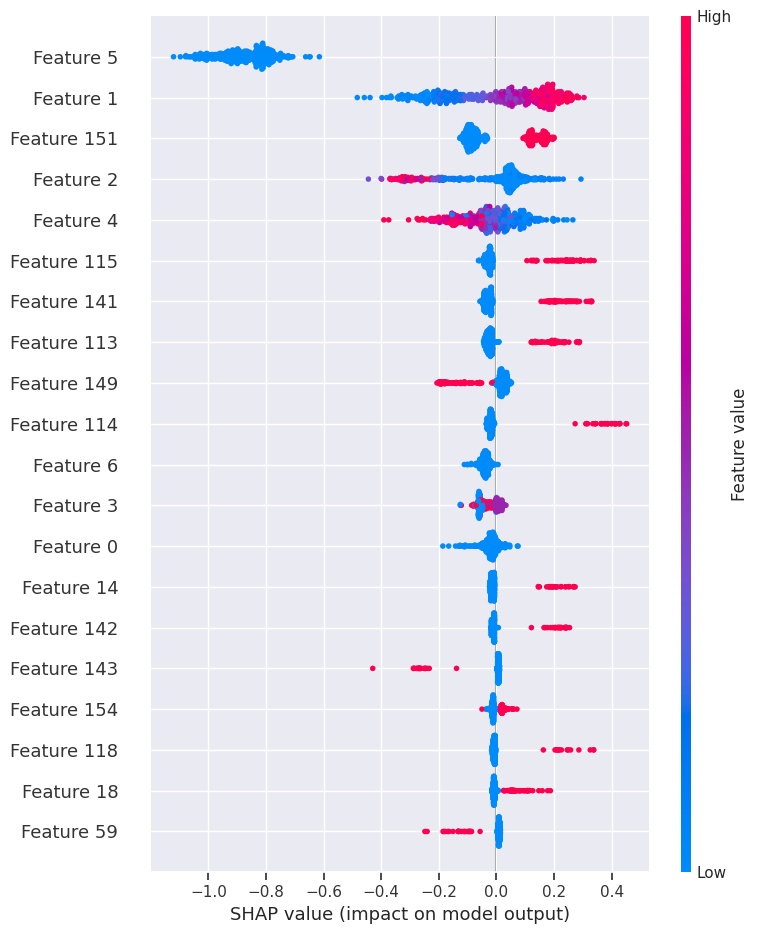

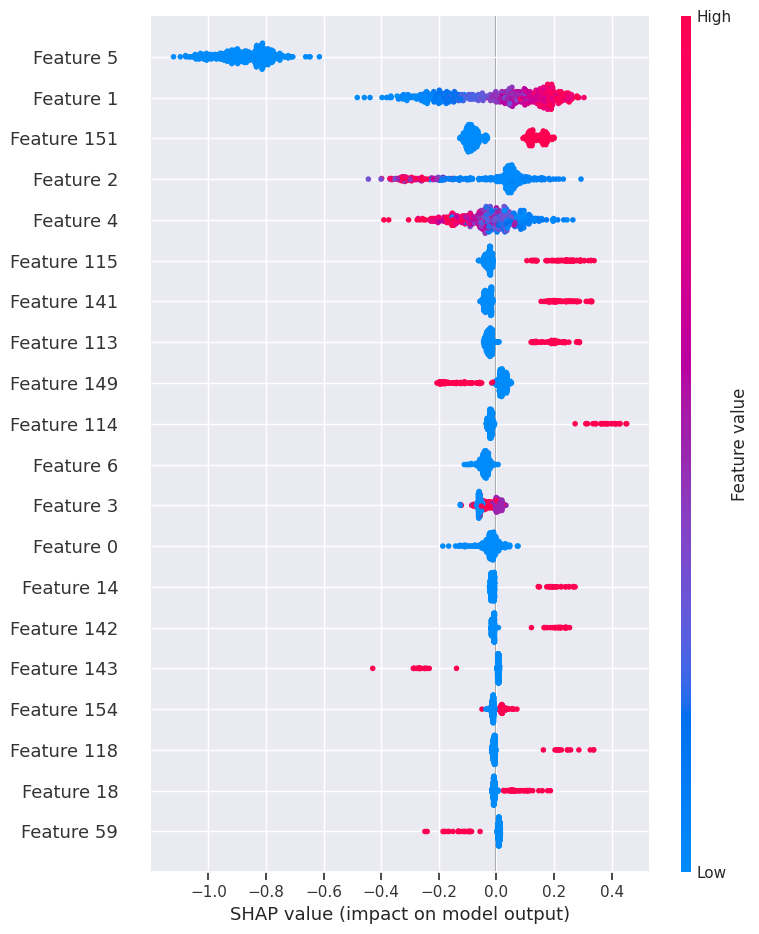

SHAP plots rendered and saved with prefix: artifacts/shap_plot


In [43]:
sns.set()

def get_preprocessor_and_model(pipeline):
    try:
        steps = getattr(pipeline, "steps", None)
        if steps and len(steps) >= 2:
            return steps[0][1], steps[-1][1]
    except Exception:
        pass
    try:
        named = getattr(pipeline, "named_steps", None)
        if named and len(named) >= 2:
            keys = list(named.keys())
            return named[keys[0]], named[keys[-1]]
    except Exception:
        pass
    return None, pipeline

def infer_feature_names(preprocessor, Xdf):
    try:
        if hasattr(preprocessor, "get_feature_names_out"):
            try:
                return list(preprocessor.get_feature_names_out(Xdf.columns))
            except Exception:
                return list(preprocessor.get_feature_names_out())
    except Exception:
        pass
    try:
        if hasattr(preprocessor, "transformers_"):
            cols = []
            for name, transformer, col_spec in preprocessor.transformers_:
                if col_spec in ("drop", "remainder") or col_spec is None:
                    continue
                if isinstance(col_spec, (list, tuple, np.ndarray)):
                    enc = None
                    if hasattr(transformer, "named_steps"):
                        for step in getattr(transformer, "steps", []):
                            if step[1].__class__.__name__.lower().startswith("onehot"):
                                enc = step[1]; break
                    else:
                        if transformer.__class__.__name__.lower().startswith("onehot"):
                            enc = transformer
                    if enc is not None and hasattr(enc, "categories_"):
                        for j, c in enumerate(col_spec):
                            cats = enc.categories_[j] if len(enc.categories_) > j else []
                            if len(cats) > 0:
                                cols.extend([f"{c}__{str(cat)}" for cat in cats])
                            else:
                                cols.append(c)
                    else:
                        cols.extend(list(col_spec))
                elif isinstance(col_spec, str):
                    cols.append(col_spec)
            if cols:
                seen = set(); ordered=[]
                for c in cols:
                    if c not in seen:
                        seen.add(c); ordered.append(c)
                return ordered
    except Exception:
        pass
    return None

def load_shap_artifact(path):
    data = joblib.load(path)
    return data

def to_dense_if_sparse(x):
    try:
        if sp.issparse(x):
            return x.toarray()
    except Exception:
        pass
    return x

def normalize_shap_object(shap_obj):
    """
    Convert any sparse inner arrays to dense numpy arrays so plotting won't error.
    Accepts shap.Explanation or raw arrays. Returns a normalized object suitable for shap.summary_plot.
    """
    # shap.Explanation case
    try:
        import shap
    except Exception:
        raise RuntimeError("Install shap to run plotting: pip install shap")

    if hasattr(shap_obj, "values") or hasattr(shap_obj, "data"):
        # convert values and data if they are sparse
        vals = getattr(shap_obj, "values", None)
        data = getattr(shap_obj, "data", None)
        base_values = getattr(shap_obj, "base_values", None)
        # convert sparse to dense where applicable
        if sp.issparse(vals):
            vals = vals.toarray()
        if sp.issparse(data):
            data = data.toarray()
        # Build a new Explanation if needed
        try:
            expl = shap.Explanation(values=vals, base_values=base_values, data=data, feature_names=getattr(shap_obj, "feature_names", None))
            return expl
        except Exception:
            return shap_obj
    else:
        # raw numpy array or list
        arr = np.array(shap_obj)
        if arr.ndim == 3:
            # handle (n_samples, n_outputs, n_features) by collapsing outputs if single-output or take mean
            if arr.shape[1] == 1:
                arr2 = arr[:,0,:]
                return arr2
            else:
                # take mean across outputs as heuristic
                arr2 = arr.mean(axis=1)
                return arr2
        return arr

def plot_shap(shap_vals, feature_names=None, out_prefix=None):
    import shap
    shap_vals = normalize_shap_object(shap_vals)
    if hasattr(shap_vals, "values") or hasattr(shap_vals, "data"):
        # shap.Explanation
        plt.figure(figsize=(8,6))
        shap.summary_plot(shap_vals, show=True)
        if out_prefix:
            plt.savefig(out_prefix + "_summary.png", bbox_inches='tight')
        plt.close()
        plt.figure(figsize=(8,6))
        shap.summary_plot(shap_vals, plot_type='dot', show=True)
        if out_prefix:
            plt.savefig(out_prefix + "_beeswarm.png", bbox_inches='tight')
        plt.close()
    else:
        arr = np.array(shap_vals)
        if arr.ndim == 2:
            if feature_names is None:
                feature_names = [f"f{i}" for i in range(arr.shape[1])]
            expl = shap.Explanation(values=arr, base_values=np.zeros(arr.shape[0]), data=None, feature_names=feature_names)
            plt.figure(figsize=(8,6))
            shap.summary_plot(expl, show=True)
            if out_prefix:
                plt.savefig(out_prefix + "_summary.png", bbox_inches='tight')
            plt.close()
            plt.figure(figsize=(8,6))
            shap.summary_plot(expl, plot_type='dot', show=True)
            if out_prefix:
                plt.savefig(out_prefix + "_beeswarm.png", bbox_inches='tight')
            plt.close()
        else:
            print("Unexpected SHAP shape for plotting:", arr.shape)

def main(args):
    try:
        import shap
    except Exception:
        print("Install shap (pip install shap) to run this script.")
        sys.exit(1)

    pipeline = joblib.load(args.pipeline)
    shap_data = load_shap_artifact(args.shap)
    Xdf = pd.read_csv(args.X) if args.X and os.path.exists(args.X) else None

    preprocessor, model = get_preprocessor_and_model(pipeline)
    feature_names = None
    if preprocessor is not None and Xdf is not None:
        feature_names = infer_feature_names(preprocessor, Xdf)

    shap_vals = shap_data.get('shap_values') if isinstance(shap_data, dict) else shap_data

    out_prefix = args.out_prefix or 'artifacts/shap_plot'
    if feature_names is None and isinstance(shap_data, dict) and shap_data.get('X_shape') is not None:
        n_feat = int(shap_data['X_shape'][1])
        feature_names = [f"f{i}" for i in range(n_feat)]
        print("Using generic feature names f0..f{n-1}")

    plot_shap(shap_vals, feature_names=feature_names, out_prefix=out_prefix)
    print("SHAP plots rendered and saved with prefix:", out_prefix)

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument('--pipeline', default='artifacts/lgbm_pipeline_holdout.pkl')
    parser.add_argument('--shap', default='artifacts/shap_values_no_leak.pkl')
    parser.add_argument('--X', default='artifacts/work_no_leak.csv', help='CSV used to infer feature names (optional)')
    parser.add_argument('--out_prefix', default='artifacts/shap_plot')
    parsed, unknown = parser.parse_known_args()
    main(parsed)

In [44]:
# adjust paths if needed
pipeline_path = 'artifacts/lgbm_pipeline_holdout.pkl'
X_path = 'artifacts/work_no_leak.csv'

pipe = joblib.load(pipeline_path)

# helper to get preprocessor
def get_preprocessor(pipe):
    steps = getattr(pipe, "steps", None)
    if steps and len(steps) >= 2:
        return steps[0][1]
    named = getattr(pipe, "named_steps", None)
    if named and len(named) >= 2:
        keys = list(named.keys())
        return named[keys[0]]
    return None

preproc = get_preprocessor(pipe)
print("Preprocessor type:", type(preproc).__name__)

# Best-effort: expected input names for the preprocessor
expected = None
if hasattr(preproc, "feature_names_in_"):
    try:
        expected = list(preproc.feature_names_in_)
        print("Obtained preproc.feature_names_in_")
    except Exception:
        expected = None

if expected is None and hasattr(preproc, "transformers_"):
    # assemble names from transformers_ where specs are explicit lists/tuples
    cols = []
    for name, transformer, col_spec in preproc.transformers_:
        if col_spec in ("drop", "remainder", None):
            continue
        if isinstance(col_spec, (list, tuple, np.ndarray)):
            cols.extend(list(col_spec))
        elif isinstance(col_spec, str):
            cols.append(col_spec)
    expected = cols if cols else None
    if expected is not None:
        print("Inferred expected columns from ColumnTransformer.transformers_")

if not expected:
    print("Could not infer expected column names from preprocessor; aborting early.")
    raise SystemExit(1)

# Make sure we show exact representation of expected names
print("\nEXPECTED columns (count={}):".format(len(expected)))
for i, c in enumerate(expected[:200]):
    print(f"{i:3d}: {repr(c)}")

# Load X and inspect its column labels
Xdf = pd.read_csv(X_path)
print("\nOriginal Xdf.columns (first 50 shown) and types:")
for i, c in enumerate(list(Xdf.columns)[:50]):
    print(f"{i:3d}: {repr(c)}   (type={type(c)})")

# Detect duplicates in Xdf columns
cols_list = list(Xdf.columns)
dupe_flags = pd.Series(cols_list).duplicated(keep=False).values
dupes = [c for i, c in enumerate(cols_list) if dupe_flags[i]]
if dupes:
    print("\nWARNING: duplicate column labels detected in Xdf (showing some):")
    pprint.pprint(sorted(set(dupes))[:50])
else:
    print("\nNo duplicate column labels detected in Xdf.")

# Normalize Xdf column names (safe transform):
# - ensure strings, strip whitespace, optionally lower-case (comment/uncomment as you prefer)
norm_map = {c: str(c).strip() for c in Xdf.columns}
# If you want case-insensitive normalization uncomment the next line:
# norm_map = {c: str(c).strip().lower() for c in Xdf.columns}

Xdf.rename(columns=norm_map, inplace=True)
print("\nAfter normalization (strip): first 50 columns:")
for i, c in enumerate(list(Xdf.columns)[:50]):
    print(f"{i:3d}: {repr(c)}")

# Also normalize expected names the same way so we compare apples-to-apples
expected_norm = [str(c).strip() for c in expected]   # if you lowercased above, apply .lower() here too

missing = [c for c in expected_norm if c not in Xdf.columns]
present = [c for c in expected_norm if c in Xdf.columns]
print(f"\nExpected normalized count: {len(expected_norm)}. Present: {len(present)}. Missing: {len(missing)}")
if missing:
    print("Missing expected columns (showing up to 200):")
    pprint.pprint(missing[:200])

# Add any missing expected columns with NaN
for c in missing:
    Xdf[c] = np.nan
print(f"Added {len(missing)} missing columns as NaN (if any). Now Xdf columns count: {len(Xdf.columns)}")

# Reorder Xdf cols to put expected columns first (ColumnTransformer prefers this pattern)
present_expected = [c for c in expected_norm if c in Xdf.columns]
extras = [c for c in Xdf.columns if c not in present_expected]
Xdf = Xdf[present_expected + extras]

print("\nFinal Xdf shape and first columns order check:")
print("Xdf.shape:", Xdf.shape)
print("First 30 columns now:")
for i, c in enumerate(list(Xdf.columns)[:30]):
    print(f"{i:3d}: {repr(c)}")

# Attempt transform
try:
    X_trans = preproc.transform(Xdf)
    if sp.issparse(X_trans):
        print("transformed matrix is sparse; converting to dense for diagnostics")
        X_trans = X_trans.toarray()
    print("Transform succeeded. X_trans shape:", X_trans.shape)
except Exception as e:
    print("\nTransform FAILED with error:\n", repr(e))
    set_expected = set(expected_norm)
    set_cols = set(Xdf.columns)
    diff = set_expected - set_cols
    print("Missing after repair:", diff)
    lower_map = {c.lower(): c for c in Xdf.columns}
    close_matches = {}
    for c in expected_norm:
        lc = c.lower()
        if lc in lower_map:
            close_matches[c] = lower_map[lc]
    if close_matches:
        print("Case-insensitive matches found (expected->actual):")
        pprint.pprint(close_matches)
    raise

Preprocessor type: ColumnTransformer
Obtained preproc.feature_names_in_

EXPECTED columns (count=16):
  0: 'vehicle_id'
  1: 'year'
  2: 'engine_index'
  3: 'engine_cylinders'
  4: 'engine_displacement'
  5: 'city_mpg_ft1'
  6: 'unrounded_city_mpg_ft1'
  7: 'city_mpg_ft2'
  8: 'make'
  9: 'model'
 10: 'class'
 11: 'drive'
 12: 'vehicle_age'
 13: 'engine_displacement_l'
 14: 'cylinders'
 15: 'is_electric'

Original Xdf.columns (first 50 shown) and types:
  0: 'combined_mpg_ft1'   (type=<class 'str'>)
  1: 'year'   (type=<class 'str'>)
  2: 'engine_index'   (type=<class 'str'>)
  3: 'engine_cylinders'   (type=<class 'str'>)
  4: 'engine_displacement'   (type=<class 'str'>)
  5: 'make'   (type=<class 'str'>)
  6: 'model'   (type=<class 'str'>)
  7: 'class'   (type=<class 'str'>)
  8: 'drive'   (type=<class 'str'>)
  9: 'vehicle_age'   (type=<class 'str'>)
 10: 'engine_displacement_l'   (type=<class 'str'>)
 11: 'cylinders'   (type=<class 'str'>)
 12: 'is_electric'   (type=<class 'str'>)



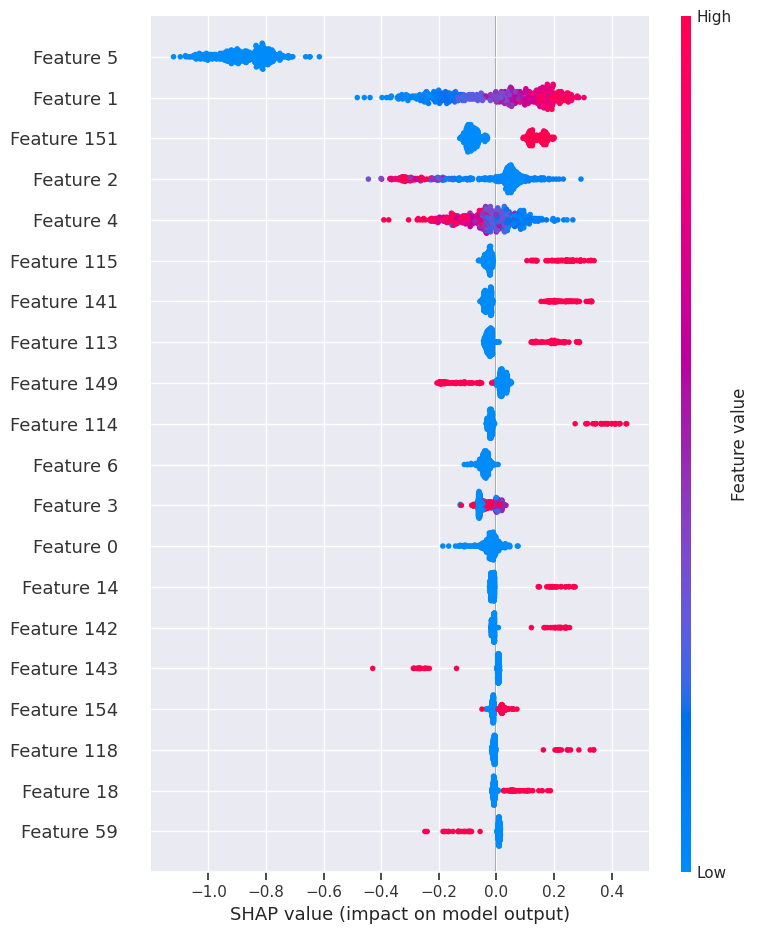

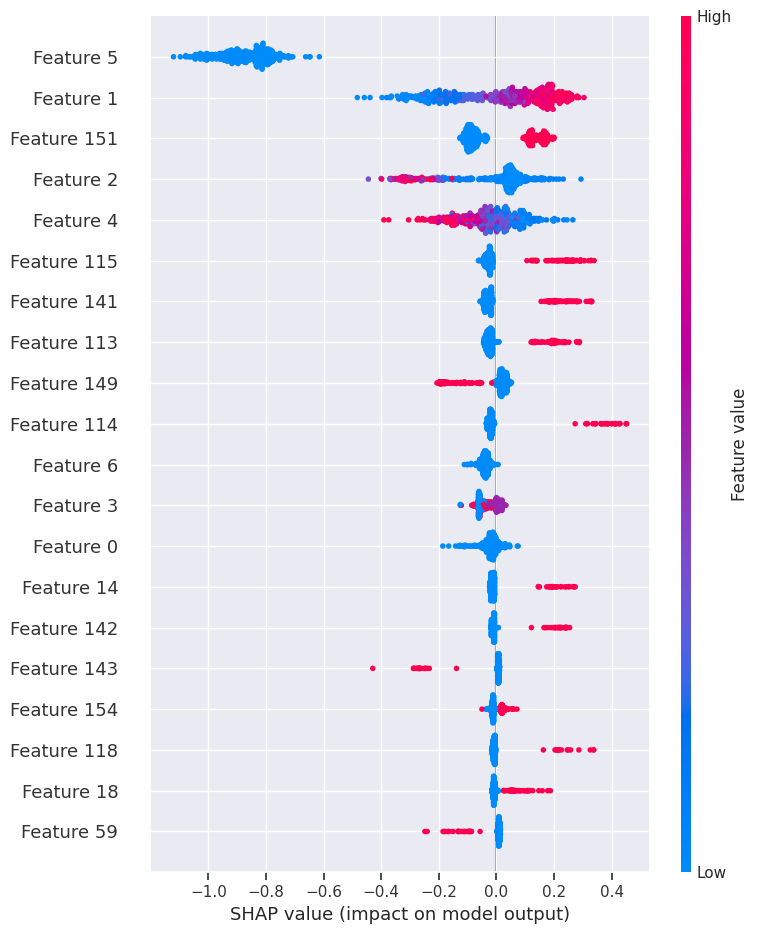

SHAP plots rendered and saved with prefix: artifacts/shap_plot


In [45]:
sns.set()

def get_preprocessor_and_model(pipeline):
    try:
        steps = getattr(pipeline, "steps", None)
        if steps and len(steps) >= 2:
            return steps[0][1], steps[-1][1]
    except Exception:
        pass
    try:
        named = getattr(pipeline, "named_steps", None)
        if named and len(named) >= 2:
            keys = list(named.keys())
            return named[keys[0]], named[keys[-1]]
    except Exception:
        pass
    return None, pipeline

def infer_feature_names(preprocessor, Xdf):
    try:
        if hasattr(preprocessor, "get_feature_names_out"):
            try:
                return list(preprocessor.get_feature_names_out(Xdf.columns))
            except Exception:
                return list(preprocessor.get_feature_names_out())
    except Exception:
        pass
    try:
        if hasattr(preprocessor, "transformers_"):
            cols = []
            for name, transformer, col_spec in preprocessor.transformers_:
                if col_spec in ("drop", "remainder") or col_spec is None:
                    continue
                if isinstance(col_spec, (list, tuple, np.ndarray)):
                    enc = None
                    if hasattr(transformer, "named_steps"):
                        for step in getattr(transformer, "steps", []):
                            if step[1].__class__.__name__.lower().startswith("onehot"):
                                enc = step[1]; break
                    else:
                        if transformer.__class__.__name__.lower().startswith("onehot"):
                            enc = transformer
                    if enc is not None and hasattr(enc, "categories_"):
                        for j, c in enumerate(col_spec):
                            cats = enc.categories_[j] if len(enc.categories_) > j else []
                            if len(cats) > 0:
                                cols.extend([f"{c}__{str(cat)}" for cat in cats])
                            else:
                                cols.append(c)
                    else:
                        cols.extend(list(col_spec))
                elif isinstance(col_spec, str):
                    cols.append(col_spec)
            if cols:
                seen = set(); ordered=[]
                for c in cols:
                    if c not in seen:
                        seen.add(c); ordered.append(c)
                return ordered
    except Exception:
        pass
    return None

def load_shap_artifact(path):
    data = joblib.load(path)
    return data

def to_dense_if_sparse(x):
    try:
        if sp.issparse(x):
            return x.toarray()
    except Exception:
        pass
    return x

def normalize_shap_object(shap_obj):

    # shap.Explanation case
    try:
        import shap
    except Exception:
        raise RuntimeError("Install shap to run plotting: pip install shap")

    if hasattr(shap_obj, "values") or hasattr(shap_obj, "data"):
        # shap.Explanation-like
        # convert values and data if they are sparse
        vals = getattr(shap_obj, "values", None)
        data = getattr(shap_obj, "data", None)
        base_values = getattr(shap_obj, "base_values", None)
        # convert sparse to dense where applicable
        if sp.issparse(vals):
            vals = vals.toarray()
        if sp.issparse(data):
            data = data.toarray()
        # Build a new Explanation if needed
        try:
            expl = shap.Explanation(values=vals, base_values=base_values, data=data, feature_names=getattr(shap_obj, "feature_names", None))
            return expl
        except Exception:
            return shap_obj
    else:
        # raw numpy array or list
        arr = np.array(shap_obj)
        if arr.ndim == 3:
            # handle (n_samples, n_outputs, n_features) by collapsing outputs if single-output or take mean
            if arr.shape[1] == 1:
                arr2 = arr[:,0,:]
                return arr2
            else:
                # take mean across outputs as heuristic
                arr2 = arr.mean(axis=1)
                return arr2
        return arr

def plot_shap(shap_vals, feature_names=None, out_prefix=None):
    import shap
    shap_vals = normalize_shap_object(shap_vals)
    if hasattr(shap_vals, "values") or hasattr(shap_vals, "data"):
        # shap.Explanation
        plt.figure(figsize=(8,6))
        shap.summary_plot(shap_vals, show=True)
        if out_prefix:
            plt.savefig(out_prefix + "_summary.png", bbox_inches='tight')
        plt.close()
        plt.figure(figsize=(8,6))
        shap.summary_plot(shap_vals, plot_type='dot', show=True)
        if out_prefix:
            plt.savefig(out_prefix + "_beeswarm.png", bbox_inches='tight')
        plt.close()
    else:
        arr = np.array(shap_vals)
        if arr.ndim == 2:
            if feature_names is None:
                feature_names = [f"f{i}" for i in range(arr.shape[1])]
            expl = shap.Explanation(values=arr, base_values=np.zeros(arr.shape[0]), data=None, feature_names=feature_names)
            plt.figure(figsize=(8,6))
            shap.summary_plot(expl, show=True)
            if out_prefix:
                plt.savefig(out_prefix + "_summary.png", bbox_inches='tight')
            plt.close()
            plt.figure(figsize=(8,6))
            shap.summary_plot(expl, plot_type='dot', show=True)
            if out_prefix:
                plt.savefig(out_prefix + "_beeswarm.png", bbox_inches='tight')
            plt.close()
        else:
            print("Unexpected SHAP shape for plotting:", arr.shape)

def main(args):
    try:
        import shap
    except Exception:
        print("Install shap (pip install shap) to run this script.")
        sys.exit(1)

    pipeline = joblib.load(args.pipeline)
    shap_data = load_shap_artifact(args.shap)
    Xdf = pd.read_csv(args.X) if args.X and os.path.exists(args.X) else None

    preprocessor, model = get_preprocessor_and_model(pipeline)
    feature_names = None
    if preprocessor is not None and Xdf is not None:
        feature_names = infer_feature_names(preprocessor, Xdf)

    shap_vals = shap_data.get('shap_values') if isinstance(shap_data, dict) else shap_data

    out_prefix = args.out_prefix or 'artifacts/shap_plot'
    if feature_names is None and isinstance(shap_data, dict) and shap_data.get('X_shape') is not None:
        n_feat = int(shap_data['X_shape'][1])
        feature_names = [f"f{i}" for i in range(n_feat)]
        print("Using generic feature names f0..f{n-1}")

    plot_shap(shap_vals, feature_names=feature_names, out_prefix=out_prefix)
    print("SHAP plots rendered and saved with prefix:", out_prefix)

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument('--pipeline', default='artifacts/lgbm_pipeline_holdout.pkl')
    parser.add_argument('--shap', default='artifacts/shap_values_no_leak.pkl')
    parser.add_argument('--X', default='artifacts/work_no_leak.csv', help='CSV used to infer feature names (optional)')
    parser.add_argument('--out_prefix', default='artifacts/shap_plot')
    parsed, unknown = parser.parse_known_args()
    main(parsed)

In [46]:
def build_preprocessor(X):
    from sklearn.pipeline import make_pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.compose import make_column_transformer

    # detect numeric and categorical features from the DataFrame X
    num_features = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

    numeric_transformer = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())

    # one-hot encoder kwargs compatible with scikit-learn version
    ohe_kwargs = {"handle_unknown": "ignore"}
    ohe_sig = inspect.signature(OneHotEncoder).parameters
    if "sparse_output" in ohe_sig:
        ohe_kwargs["sparse_output"] = False
    else:
        ohe_kwargs["sparse"] = False

    if len(cat_features) > 0:
        categorical_transformer = make_pipeline(SimpleImputer(strategy='constant', fill_value='MISSING'),
                                                OneHotEncoder(**ohe_kwargs))
        preprocessor = make_column_transformer((numeric_transformer, num_features),
                                               (categorical_transformer, cat_features),
                                               remainder='drop')
    else:
        preprocessor = make_column_transformer((numeric_transformer, num_features), remainder='drop')

    return preprocessor, num_features, cat_features

def get_preprocessor_and_model(pipeline):
    try:
        steps = getattr(pipeline, "steps", None)
        if steps and len(steps) >= 2:
            preprocessor = steps[0][1]
            model = steps[-1][1]
            return preprocessor, model
    except Exception:
        pass
    try:
        named = getattr(pipeline, "named_steps", None)
        if named and len(named) >= 2:
            keys = list(named.keys())
            preprocessor = named[keys[0]]
            model = named[keys[-1]]
            return preprocessor, model
    except Exception:
        pass
    return None, pipeline

def main(args):
    # load data
    Xdf = pd.read_csv(args.X)
    if args.target not in Xdf.columns:
        raise ValueError(f"Target column '{args.target}' not found in {args.X}")

    # Prepare X, y (drop rows with missing target)
    df_model = Xdf[Xdf[args.target].notna()].reset_index(drop=True).copy()
    y = df_model[args.target]
    X = df_model.drop(columns=[args.target])

    # Build preprocessor
    preproc, num_feats, cat_feats = build_preprocessor(X)
    print(f"Numeric features: {len(num_feats)}, Categorical features: {len(cat_feats)}")

    # Choose model: LightGBM if available else RandomForest
    try:
        from lightgbm import LGBMRegressor
        model = LGBMRegressor(n_estimators=args.n_estimators, learning_rate=args.learning_rate,
                              random_state=args.random_state, n_jobs=args.n_jobs)
        model_name = "LightGBM"
    except Exception:
        from sklearn.ensemble import RandomForestRegressor
        model = RandomForestRegressor(n_estimators=200, random_state=args.random_state, n_jobs=args.n_jobs)
        model_name = "RandomForest"
    print("Using model:", model_name)

    # Build full pipeline
    from sklearn.pipeline import make_pipeline
    pipeline = make_pipeline(preproc, model)

    # Fit pipeline on full no-leak data
    print("Fitting pipeline on no-leak data...")
    pipeline.fit(X, y)
    os.makedirs(os.path.dirname(args.pipeline_out) or ".", exist_ok=True)
    joblib.dump(pipeline, args.pipeline_out)
    print("Saved re-fitted pipeline to:", args.pipeline_out)

    # Transform the full X to numeric matrix for SHAP (may be dense or sparse).
    preprocessor, fitted_model = get_preprocessor_and_model(pipeline)
    if preprocessor is None:
        raise RuntimeError("Could not extract preprocessor from pipeline")

    # Ensure DataFrame includes expected columns (if preprocessor expects feature_names_in_)
    # Add missing expected column names as NaN if necessary (defensive)
    expected_cols = None
    if hasattr(preprocessor, "feature_names_in_"):
        try:
            expected_cols = list(preprocessor.feature_names_in_)
        except Exception:
            expected_cols = None
    if expected_cols:
        # normalize and add missing
        missing = [c for c in expected_cols if c not in X.columns]
        if missing:
            print("Adding missing expected columns to X (as NaN):", missing)
            for c in missing:
                X[c] = np.nan
        # reorder so expected columns appear first (helpful)
        present_expected = [c for c in expected_cols if c in X.columns]
        extras = [c for c in X.columns if c not in present_expected]
        X = X[present_expected + extras]

    print("Transforming features using fitted preprocessor...")
    X_trans = preprocessor.transform(X)
    # convert sparse -> dense for SHAP if necessary
    try:
        import scipy.sparse as sp
        if sp.issparse(X_trans):
            X_trans = X_trans.toarray()
    except Exception:
        pass
    print("Transformed matrix shape:", getattr(X_trans, "shape", None))

    # sample rows for SHAP (use a reproducible random seed)
    rng = np.random.RandomState(args.random_state)
    n_all = X_trans.shape[0]
    sample_n = min(args.sample_n, n_all)
    sample_idx = rng.choice(np.arange(n_all), size=sample_n, replace=False)
    Xs = X_trans[sample_idx]

    # compute SHAP using TreeExplainer where possible
    try:
        import shap
    except Exception:
        raise RuntimeError("shap is required to compute explanations. Install with `pip install shap`")

    print("Computing SHAP values on", Xs.shape[0], "rows...")
    try:
        explainer = shap.TreeExplainer(fitted_model)
        shap_values = explainer(Xs)   # returns shap.Explanation on modern shap versions
    except Exception as e:
        # fallback to older API
        try:
            explainer = shap.TreeExplainer(fitted_model)
            shap_vals_raw = explainer.shap_values(Xs)
            shap_values = shap_vals_raw
        except Exception as e2:
            raise RuntimeError(f"SHAP computation failed: {e}; fallback also failed: {e2}")

    # Save SHAP artifact
    out = {
        'shap_values': shap_values,
        'sample_index': sample_idx,
        'pipeline_path': args.pipeline_out,
        'X_shape': X_trans.shape
    }
    os.makedirs(os.path.dirname(args.shap_out) or ".", exist_ok=True)
    joblib.dump(out, args.shap_out)
    print("Saved SHAP artifact to:", args.shap_out)

    # Optionally render summary plots if requested and running interactively
    if args.plot:
        try:
            import matplotlib.pyplot as plt
            plt.rcParams['figure.dpi'] = 120
            print("Rendering SHAP summary plots (bar and beeswarm)...")
            # if shap_values is an Explanation, shap.summary_plot handles it
            try:
                shap.summary_plot(shap_values, Xs if getattr(shap_values, "data", None) is None else shap_values.data, show=True)
                shap.summary_plot(shap_values, Xs if getattr(shap_values, "data", None) is None else shap_values.data, plot_type="dot", show=True)
            except Exception:
                # Explicit arrays fallback
                vals = shap_values.values if hasattr(shap_values, "values") else np.array(shap_values)
                shap.summary_plot(vals, features=Xs, feature_names=None, show=True)
        except Exception as e:
            print("Plotting failed (continuing). Error:", e)

    # Save a short metrics/manifest JSON for provenance
    manifest = {
        'pipeline_out': args.pipeline_out,
        'shap_out': args.shap_out,
        'n_rows': int(n_all),
        'shap_sample_n': int(sample_n),
        'model_type': model_name
    }
    with open(os.path.splitext(args.shap_out)[0] + "_manifest.json", "w") as f:
        json.dump(manifest, f, indent=2)
    print("Saved manifest:", os.path.splitext(args.shap_out)[0] + "_manifest.json")

if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="Refit model on no-leak data and compute SHAP")
    parser.add_argument('--X', default='artifacts/work_no_leak.csv')
    parser.add_argument('--target', default='combined_mpg_ft1')
    parser.add_argument('--pipeline_out', default='artifacts/lgbm_no_leak_refit_pipeline.pkl')
    parser.add_argument('--shap_out', default='artifacts/shap_values_no_leak_refit.pkl')
    parser.add_argument('--sample_n', type=int, default=500)
    parser.add_argument('--n_estimators', type=int, default=1000)
    parser.add_argument('--learning_rate', type=float, default=0.05)
    parser.add_argument('--n_jobs', type=int, default=4)
    parser.add_argument('--random_state', type=int, default=42)
    parser.add_argument('--plot', action='store_true', help='Render SHAP summary plots (if running interactively)')
    parsed, unknown = parser.parse_known_args()
    # unknown args (e.g., Jupyter -f flags) are ignored
    main(parsed)

Numeric features: 7, Categorical features: 4
Using model: LightGBM
Fitting pipeline on no-leak data...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004918 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1637
[LightGBM] [Info] Number of data points in the train set: 38113, number of used features: 606
[LightGBM] [Info] Start training from score 20.216068
Saved re-fitted pipeline to: artifacts/lgbm_no_leak_refit_pipeline.pkl
Transforming features using fitted preprocessor...
Transformed matrix shape: (38113, 3930)
Computing SHAP values on 500 rows...
Saved SHAP artifact to: artifacts/shap_values_no_leak_refit.pkl
Saved manifest: artifacts/shap_values_no_leak_refit_manifest.json


Transformed X shape: (38113, 3930)
Saved X_shape: (38113, 3930) sample_idx len: 500
SHAP vals shape: (500, 3930)
Using 3930 feature names for plotting
Saved feature importance CSV: artifacts/shap_refit_feature_importance_refit.csv


,feature,mean_abs_shap
0,pipeline-1__engine_displacement,2.838276
1,pipeline-1__year,1.808727
2,pipeline-2__drive_Front-Wheel Drive,0.972762
3,pipeline-1__engine_index,0.486428
4,pipeline-1__engine_cylinders,0.323581
...,...,...
75,pipeline-2__model_Ranger Pickup 2WD,0.006468
76,pipeline-2__make_Cadillac,0.006307
77,pipeline-2__model_Wrangler 4WD,0.006258
78,pipeline-2__make_Lamborghini,0.006170


Saved grouped importance CSV: artifacts/shap_refit_grouped_importance_refit.csv


,group,mean_abs_shap
0,pipeline-1,0.782245
1,pipeline-2,0.001103


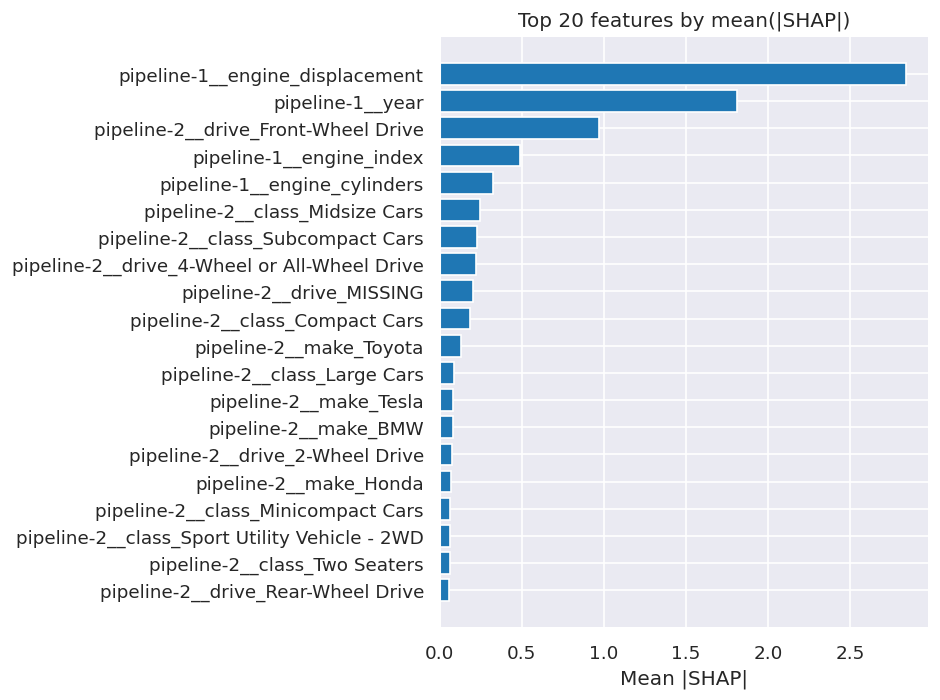

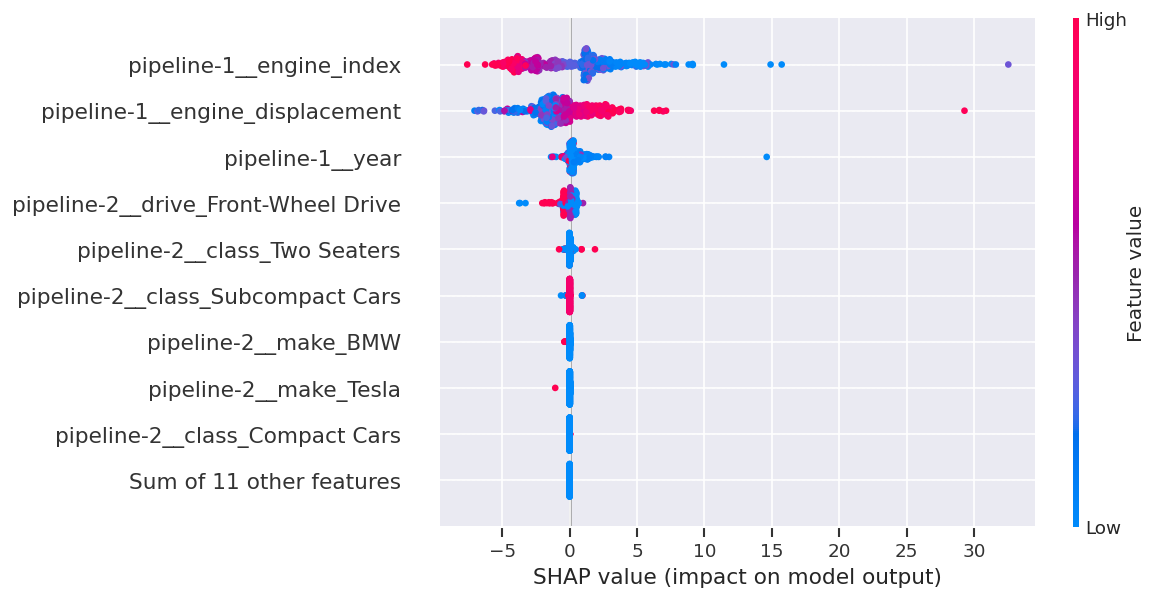

Plotted top-k SHAP beeswarm and bar.


In [47]:
# Visualize SHAP for the re-fitted no-leak pipeline
plt.rcParams['figure.dpi'] = 120

PIPELINE_PKL = 'artifacts/lgbm_no_leak_refit_pipeline.pkl'
SHAP_PKL = 'artifacts/shap_values_no_leak_refit.pkl'
X_CSV = 'artifacts/work_no_leak.csv'
TOP_K = 20   # number of top features to visualize
OUT_PREFIX = 'artifacts/shap_refit'

# Load
pipeline = joblib.load(PIPELINE_PKL)
shap_art = joblib.load(SHAP_PKL)
Xdf = pd.read_csv(X_CSV)

# Extract preprocessor and model
def get_preprocessor_and_model(pipe):
    steps = getattr(pipe, "steps", None)
    if steps and len(steps) >= 2:
        return steps[0][1], steps[-1][1]
    named = getattr(pipe, "named_steps", None)
    if named and len(named) >= 2:
        keys = list(named.keys())
        return named[keys[0]], named[keys[-1]]
    return None, pipe

preproc, model = get_preprocessor_and_model(pipeline)
if preproc is None:
    raise RuntimeError("Could not extract preprocessor from pipeline")

# Align Xdf with preprocessor expected columns if possible
if hasattr(preproc, "feature_names_in_"):
    try:
        expected = list(preproc.feature_names_in_)
        # add missing expected columns if any (NaN)
        missing = [c for c in expected if c not in Xdf.columns]
        for c in missing:
            Xdf[c] = np.nan
        # reorder
        present_expected = [c for c in expected if c in Xdf.columns]
        extras = [c for c in Xdf.columns if c not in present_expected]
        Xdf = Xdf[present_expected + extras]
    except Exception:
        pass

# Transform full X (may be large) - convert sparse to dense for later use
X_trans = preproc.transform(Xdf)
if sp.issparse(X_trans):
    X_trans = X_trans.toarray()
print("Transformed X shape:", X_trans.shape)

# Extract SHAP object/array
shap_obj = shap_art.get('shap_values') if isinstance(shap_art, dict) else shap_art
sample_idx = np.array(shap_art.get('sample_index')) if isinstance(shap_art, dict) else None
saved_X_shape = shap_art.get('X_shape') if isinstance(shap_art, dict) else None
print("Saved X_shape:", saved_X_shape, "sample_idx len:", None if sample_idx is None else len(sample_idx))

# Convert SHAP to a dense numpy array if needed and collapse third dim if necessary
def shap_to_array(sh):
    # shap.Explanation
    if hasattr(sh, "values"):
        arr = np.array(sh.values)
    else:
        arr = np.array(sh)
    if arr.ndim == 3 and arr.shape[1] == 1:
        arr = arr[:,0,:]
    return arr

vals = shap_to_array(shap_obj)
print("SHAP vals shape:", vals.shape)

# Build feature names for transformed matrix
feat_names = None

try:
    if hasattr(preproc, "get_feature_names_out"):
        try:
            feat_names = list(preproc.get_feature_names_out(getattr(Xdf, 'columns', None)))
        except Exception:
            feat_names = list(preproc.get_feature_names_out())
except Exception:
    feat_names = None

# Fallback: inspect column transformer transformers_ and OneHotEncoder categories
if feat_names is None and hasattr(preproc, "transformers_"):
    cols = []
    for name, transformer, spec in preproc.transformers_:
        if spec in ("drop", "remainder", None):
            continue
        if isinstance(spec, (list, tuple, np.ndarray)):
            # attempt to expand OHE categories
            enc = None
            if hasattr(transformer, "named_steps"):
                for _, step in transformer.named_steps.items():
                    if step.__class__.__name__.lower().startswith("onehot"):
                        enc = step; break
            else:
                if transformer.__class__.__name__.lower().startswith("onehot"):
                    enc = transformer
            if enc is not None and hasattr(enc, "categories_"):
                for j, c in enumerate(spec):
                    cats = enc.categories_[j] if len(enc.categories_) > j else []
                    if len(cats) > 0:
                        cols.extend([f"{c}__{str(cat)}" for cat in cats])
                    else:
                        cols.append(c)
            else:
                cols.extend(list(spec))
        elif isinstance(spec, str):
            cols.append(spec)
    # dedupe & use as names when available
    seen=set(); feat_names=[]
    for c in cols:
        if c not in seen:
            seen.add(c); feat_names.append(c)
    # if this produced fewer names than vals width, fallback to generic names later

# Final fallback: generic names
if feat_names is None or len(feat_names) != vals.shape[1]:
    feat_names = [f"f{i}" for i in range(vals.shape[1])]
print("Using", len(feat_names), "feature names for plotting")

# Compute mean absolute SHAP per feature and save CSV
mean_abs = np.mean(np.abs(vals), axis=0)
df_feat = pd.DataFrame({'feature': feat_names, 'mean_abs_shap': mean_abs})
df_feat = df_feat.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
df_feat.to_csv(f"{OUT_PREFIX}_feature_importance_refit.csv", index=False)
print("Saved feature importance CSV:", f"{OUT_PREFIX}_feature_importance_refit.csv")
display(df_feat.head(80))

# Aggregate OHE groups (prefix before '__') to get group importances
def group_name(fn):
    if "__" in str(fn):
        return str(fn).split("__",1)[0]
    # sometimes OneHotEncoder may produce names like 'col__a' or 'pipeline-1__col__a' - handle double prefixes
    if "___" in str(fn):
        return str(fn).split("___",1)[0]
    # fallback: return original name
    return str(fn)

df_feat['group'] = df_feat['feature'].apply(group_name)
grouped = df_feat.groupby('group', as_index=False)['mean_abs_shap'].mean().sort_values('mean_abs_shap', ascending=False)
grouped.to_csv(f"{OUT_PREFIX}_grouped_importance_refit.csv", index=False)
print("Saved grouped importance CSV:", f"{OUT_PREFIX}_grouped_importance_refit.csv")
display(grouped.head(40))

# Plot top-K features (bar)
top_k = min(TOP_K, len(df_feat))
plt.figure(figsize=(8,6))
top = df_feat.head(top_k).iloc[::-1]
plt.barh(top['feature'], top['mean_abs_shap'], color='tab:blue')
plt.xlabel('Mean |SHAP|')
plt.title(f'Top {top_k} features by mean(|SHAP|)')
plt.tight_layout()
plt.show()

# Prepare arrays for beeswarm: subset to top_k features for clarity and speed
top_idx = df_feat.index[:top_k].tolist()
vals_sub = vals[:, top_idx]
# features_for_plot rows = same sample_idx used when computing SHAP
rows = sample_idx if sample_idx is not None else np.arange(vals.shape[0])
features_for_plot = X_trans[rows][:, top_idx]

try:
    expl_small = shap.Explanation(values=vals_sub, data=features_for_plot, feature_names=[df_feat.loc[i,'feature'] for i in top_idx])
    # use new API if available
    try:
        shap.plots.beeswarm(expl_small)
    except Exception:
        shap.summary_plot(expl_small, plot_type='dot', show=True)
except Exception as e:
    # fallback: call summary_plot with arrays
    feat_names_sub = [df_feat.loc[i,'feature'] for i in top_idx]
    shap.summary_plot(vals_sub, features=features_for_plot, feature_names=feat_names_sub, plot_type='dot', show=True)

print("Plotted top-k SHAP beeswarm and bar.")

In [48]:
def load_shap_array(shap_obj):
    # return 2D numpy array (n_samples, n_features)
    if hasattr(shap_obj, "values"):
        arr = np.array(shap_obj.values)
    else:
        arr = np.array(shap_obj)
    if arr.ndim == 3 and arr.shape[1] == 1:
        arr = arr[:,0,:]
    return arr

def infer_feature_names(preproc, Xdf=None):
    try:
        if hasattr(preproc, "get_feature_names_out"):
            try:
                return list(preproc.get_feature_names_out(getattr(Xdf, 'columns', None)))
            except Exception:
                return list(preproc.get_feature_names_out())
    except Exception:
        pass
    # fallback: inspect transformers_
    try:
        if hasattr(preproc, "transformers_"):
            cols = []
            for name, transformer, spec in preproc.transformers_:
                if spec in ("drop", "remainder", None):
                    continue
                if isinstance(spec, (list, tuple, np.ndarray)):
                    # try to expand OneHotEncoder categories
                    enc = None
                    if hasattr(transformer, "named_steps"):
                        for _, step in transformer.named_steps.items():
                            if step.__class__.__name__.lower().startswith("onehot"):
                                enc = step; break
                    else:
                        if transformer.__class__.__name__.lower().startswith("onehot"):
                            enc = transformer
                    if enc is not None and hasattr(enc, "categories_"):
                        for j, c in enumerate(spec):
                            cats = enc.categories_[j] if len(enc.categories_) > j else []
                            if len(cats) > 0:
                                cols.extend([f"{c}__{str(cat)}" for cat in cats])
                            else:
                                cols.append(c)
                    else:
                        cols.extend(list(spec))
                elif isinstance(spec, str):
                    cols.append(spec)
            # dedupe preserving order
            seen=set(); ordered=[]
            for c in cols:
                if c not in seen:
                    seen.add(c); ordered.append(c)
            if ordered:
                return ordered
    except Exception:
        pass
    return None

def group_name(fn):
    if "__" in str(fn):
        return str(fn).split("__",1)[0]
    return str(fn)

def main(args):
    os.makedirs(os.path.dirname(args.out_prefix) or ".", exist_ok=True)

    pipeline = joblib.load(args.pipeline)
    shap_art = joblib.load(args.shap)
    Xdf = pd.read_csv(args.X) if args.X and os.path.exists(args.X) else None

    # extract preprocessor
    preproc = None
    steps = getattr(pipeline, "steps", None)
    if steps and len(steps) >= 2:
        preproc = steps[0][1]
    elif hasattr(pipeline, "named_steps"):
        ks = list(pipeline.named_steps.keys())
        if ks:
            preproc = pipeline.named_steps[ks[0]]

    if preproc is None:
        raise RuntimeError("Could not extract preprocessor from pipeline")

    shap_obj = shap_art.get('shap_values') if isinstance(shap_art, dict) else shap_art
    vals = load_shap_array(shap_obj)
    n_samples, n_feats = vals.shape

    # infer feature names
    feat_names = infer_feature_names(preproc, Xdf)
    if feat_names is None or len(feat_names) != n_feats:
        feat_names = [f"f{i}" for i in range(n_feats)]

    # build dataframe of mean |SHAP|
    mean_abs = np.mean(np.abs(vals), axis=0)
    df_feat = pd.DataFrame({'feature': feat_names, 'mean_abs_shap': mean_abs})
    df_feat = df_feat.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

    # save feature importance
    feat_csv = f"{args.out_prefix}_feature_importance_refit.csv"
    df_feat.to_csv(feat_csv, index=False)
    print("Saved feature importance CSV:", feat_csv)

    # grouped importance
    df_feat['group'] = df_feat['feature'].apply(group_name)
    grouped = df_feat.groupby('group', as_index=False)['mean_abs_shap'].mean().sort_values('mean_abs_shap', ascending=False)
    grouped_csv = f"{args.out_prefix}_grouped_importance_refit.csv"
    grouped.to_csv(grouped_csv, index=False)
    print("Saved grouped importance CSV:", grouped_csv)

    # top-k plotting
    top_k = min(args.top_k, len(df_feat))
    top = df_feat.head(top_k).iloc[::-1]

    plt.figure(figsize=(8, max(4, top_k * 0.25)))
    plt.barh(top['feature'], top['mean_abs_shap'], color='tab:blue')
    plt.xlabel('Mean |SHAP|')
    plt.title(f'Top {top_k} features by mean(|SHAP|)')
    bar_png = f"{args.out_prefix}_topk_bar.png"
    plt.tight_layout()
    plt.savefig(bar_png, dpi=150)
    plt.close()
    print("Saved bar plot:", bar_png)

    # beeswarm for top_k (use saved sample rows if available)
    sample_idx = shap_art.get('sample_index') if isinstance(shap_art, dict) else None

    # transform X and get features_for_plot (sample rows)
    X_trans = preproc.transform(Xdf) if Xdf is not None else None
    if sp.issparse(X_trans):
        X_trans = X_trans.toarray()
    if X_trans is None:
        features_for_plot = None
    else:
        rows = np.array(sample_idx) if sample_idx is not None else np.arange(n_samples)
        features_for_plot = X_trans[rows][:, :n_feats]

    # use subset arrays for beeswarm to keep plot readable (top_k)
    import shap as _shap
    top_idx = df_feat.index[:top_k].tolist()
    vals_sub = vals[:, top_idx]
    feat_sub = None
    if features_for_plot is not None:
        feat_sub = features_for_plot[:, top_idx]

    beeswarm_png = f"{args.out_prefix}_topk_beeswarm.png"
    try:
        if feat_sub is not None:
            expl_small = _shap.Explanation(values=vals_sub, data=feat_sub, feature_names=[df_feat.loc[i,'feature'] for i in top_idx])
            try:
                _shap.plots.beeswarm(expl_small, show=False)
            except Exception:
                _shap.summary_plot(expl_small, plot_type='dot', show=False)
        else:
            expl_small = _shap.Explanation(values=vals_sub, feature_names=[df_feat.loc[i,'feature'] for i in top_idx])
            _shap.summary_plot(expl_small, plot_type='dot', show=False)
        plt.savefig(beeswarm_png, dpi=150)
        plt.close()
        print("Saved beeswarm plot:", beeswarm_png)
    except Exception as e:
        print("Beeswarm plotting failed:", e)

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument('--pipeline', default='artifacts/lgbm_no_leak_refit_pipeline.pkl')
    parser.add_argument('--shap', default='artifacts/shap_values_no_leak_refit.pkl')
    parser.add_argument('--X', default='artifacts/work_no_leak.csv')
    parser.add_argument('--out_prefix', default='artifacts/shap_refit')
    parser.add_argument('--top_k', type=int, default=20)
    args, _ = parser.parse_known_args()
    main(args)

Saved feature importance CSV: artifacts/shap_refit_feature_importance_refit.csv
Saved grouped importance CSV: artifacts/shap_refit_grouped_importance_refit.csv
Saved bar plot: artifacts/shap_refit_topk_bar.png
Saved beeswarm plot: artifacts/shap_refit_topk_beeswarm.png


In [49]:
def compute_group_mae(hold_df, work_df, group_col, target_col='y_true', pred_col='y_pred', min_n=5):
    # join group values from work_df by index (holdout index should align with original work index)
    if group_col in work_df.columns:
        groups = work_df.loc[hold_df.index, group_col].fillna('MISSING')
    else:
        # fallback: if group not present, try in holdout
        if group_col in hold_df.columns:
            groups = hold_df[group_col].fillna('MISSING')
        else:
            raise KeyError(f"Group column {group_col} not found in work or holdout")
    df = pd.DataFrame({'group': groups.values, 'y_true': hold_df[target_col].values, 'y_pred': hold_df[pred_col].values})
    stats = df.groupby('group').apply(lambda g: pd.Series({
        'MAE': (g['y_true'] - g['y_pred']).abs().mean(),
        'N': len(g)
    })).reset_index()
    stats = stats.sort_values('MAE', ascending=False)
    stats_filtered = stats[stats['N'] >= min_n].copy()
    return stats, stats_filtered

def main(args):
    os.makedirs(os.path.dirname(args.out_prefix) or ".", exist_ok=True)
    hold = pd.read_csv(args.holdout)
    work = pd.read_csv(args.work)
    # ensure expected columns present
    if 'y_true' not in hold.columns or 'y_pred' not in hold.columns:
        raise KeyError("holdout CSV must contain 'y_true' and 'y_pred' columns")

    for g in args.groups:
        all_stats, stats_filtered = compute_group_mae(hold, work, g, min_n=args.min_n)
        csv_all = f"{args.out_prefix}_{g}_mae_all.csv"
        csv_filtered = f"{args.out_prefix}_{g}_mae_filtered.csv"
        all_stats.to_csv(csv_all, index=False)
        stats_filtered.to_csv(csv_filtered, index=False)
        print(f"Saved {csv_all} and {csv_filtered}")
        # plot top 20 worst MAE groups (filtered)
        top = stats_filtered.sort_values('MAE', ascending=False).head(20)
        plt.figure(figsize=(8, max(4, len(top)*0.3)))
        plt.barh(top['group'].astype(str), top['MAE'], color='tab:orange')
        plt.xlabel('MAE')
        plt.title(f'Top MAE by {g} (N >= {args.min_n})')
        plt.tight_layout()
        png = f"{args.out_prefix}_{g}_top_mae.png"
        plt.savefig(png, dpi=150)
        plt.close()
        print("Saved plot:", png)

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument('--holdout', default='artifacts/lgbm_no_leak_holdout_predictions.csv')
    parser.add_argument('--work', default='artifacts/work_no_leak.csv')
    parser.add_argument('--groups', nargs='+', default=['make','model','class'])
    parser.add_argument('--out_prefix', default='artifacts/group_errors')
    parser.add_argument('--min_n', type=int, default=5)
    args, _ = parser.parse_known_args()
    main(args)

Saved artifacts/group_errors_make_mae_all.csv and artifacts/group_errors_make_mae_filtered.csv
Saved plot: artifacts/group_errors_make_top_mae.png
Saved artifacts/group_errors_model_mae_all.csv and artifacts/group_errors_model_mae_filtered.csv
Saved plot: artifacts/group_errors_model_top_mae.png
Saved artifacts/group_errors_class_mae_all.csv and artifacts/group_errors_class_mae_filtered.csv
Saved plot: artifacts/group_errors_class_top_mae.png


Holdout rows: 7623, Work rows: 38113
Groups to evaluate: ['make', 'model', 'class']
Minimum group size for filtered view: 5

Group: make
Saved CSVs: artifacts/group_errors_make_mae_all.csv, artifacts/group_errors_make_mae_filtered.csv

Summary stats (filtered groups, N>=5)
Count of filtered groups: 51
MAE (filtered) - mean: 0.0051, median: 0.0013, max: 0.1003, min: 0.0000


,group,MAE,N
24,Eagle,0.100345,8.0
10,BMW,0.028030,94.0
61,Renault,0.021429,56.0
66,Sterling,0.013107,6.0
53,Oldsmobile,0.011753,233.0
18,Chevrolet,0.011086,1162.0
22,Dodge,0.008055,903.0
5,Aston Martin,0.006499,21.0
42,Lincoln,0.004701,23.0
17,Cadillac,0.004441,73.0


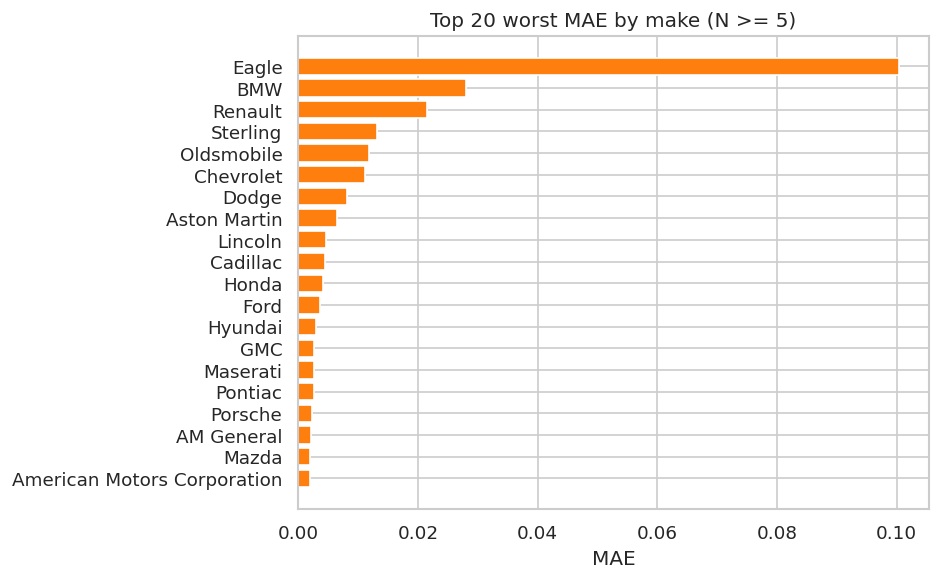

Saved plot: artifacts/group_errors_make_top_mae.png


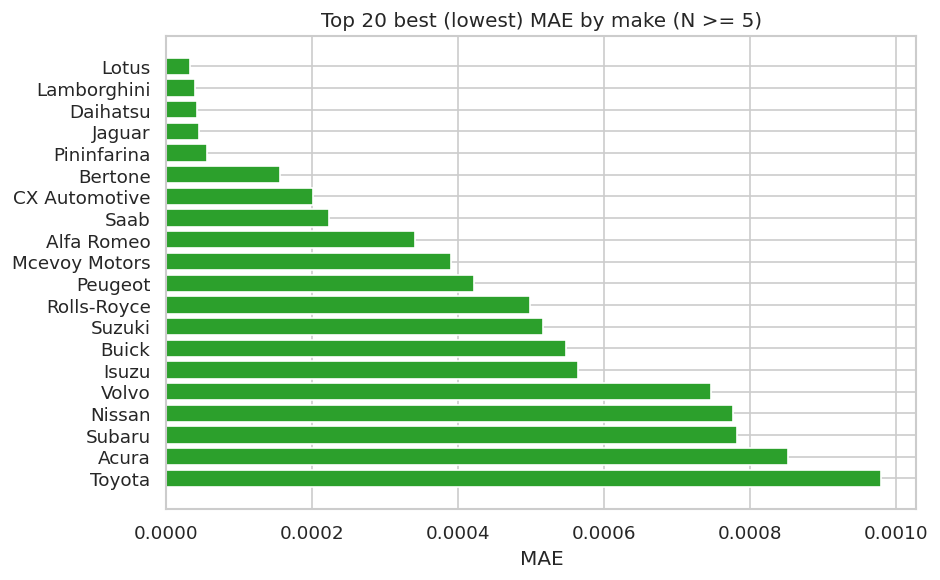

Saved plot: artifacts/group_errors_make_best_mae.png



Group: model
Saved CSVs: artifacts/group_errors_model_mae_all.csv, artifacts/group_errors_model_mae_filtered.csv

Summary stats (filtered groups, N>=5)
Count of filtered groups: 378
MAE (filtered) - mean: 0.0045, median: 0.0006, max: 0.3608, min: 0.0000


,group,MAE,N
258,Custom Cruiser Wagon,0.360765,6.0
394,K20 Pickup 4WD,0.139743,25.0
65,5 Series,0.107255,23.0
334,Fuego,0.107078,11.0
455,Omni,0.101868,31.0
389,K10 Pickup 4WD,0.084480,49.0
150,B350 Wagon 2WD,0.044741,18.0
338,G10/20 Van 2WD,0.036796,72.0
469,Power Ram50 4WD,0.036588,8.0
310,F250 Pickup 2WD,0.033245,47.0


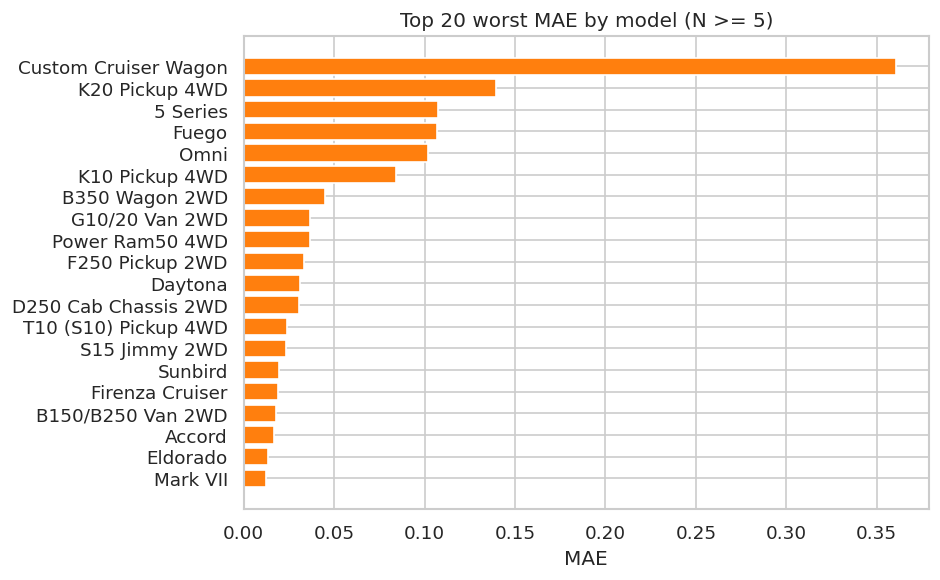

Saved plot: artifacts/group_errors_model_top_mae.png


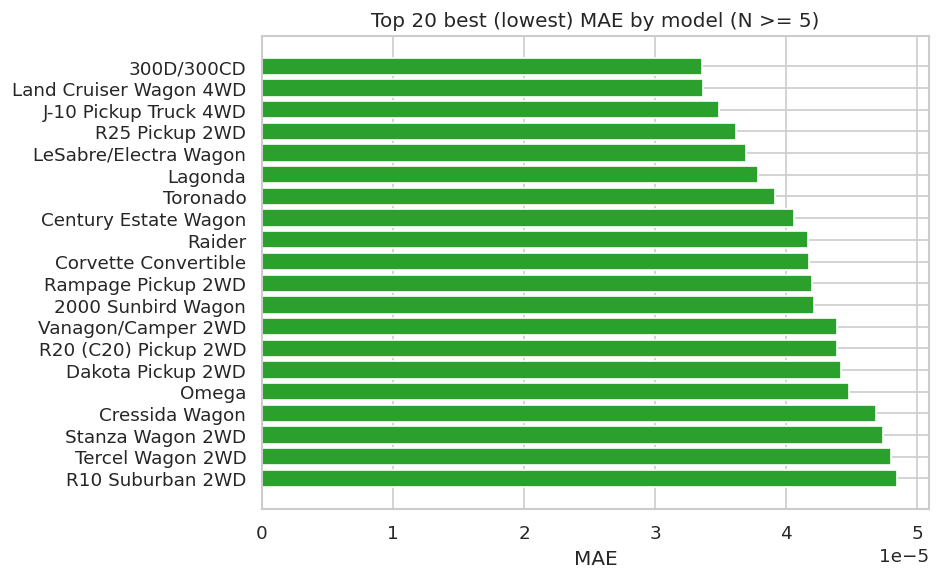

Saved plot: artifacts/group_errors_model_best_mae.png



Group: class
Saved CSVs: artifacts/group_errors_class_mae_all.csv, artifacts/group_errors_class_mae_filtered.csv

Summary stats (filtered groups, N>=5)
Count of filtered groups: 21
MAE (filtered) - mean: 0.0050, median: 0.0022, max: 0.0405, min: 0.0002


,group,MAE,N
15,Standard Pickup Trucks 4WD,0.040470,103.0
4,Midsize-Large Station Wagons,0.010800,290.0
18,Vans,0.008684,562.0
13,Standard Pickup Trucks,0.007852,884.0
0,Compact Cars,0.007074,1023.0
10,Special Purpose Vehicle 2WD,0.005976,328.0
7,Small Pickup Trucks 2WD,0.003554,126.0
5,Minicompact Cars,0.003224,102.0
16,Subcompact Cars,0.003121,1294.0
9,Small Station Wagons,0.002316,386.0


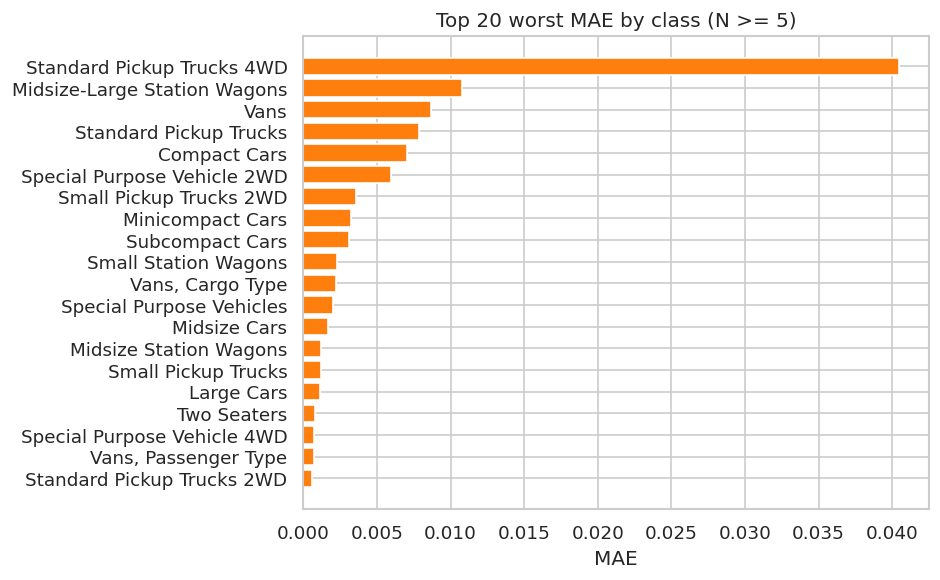

Saved plot: artifacts/group_errors_class_top_mae.png


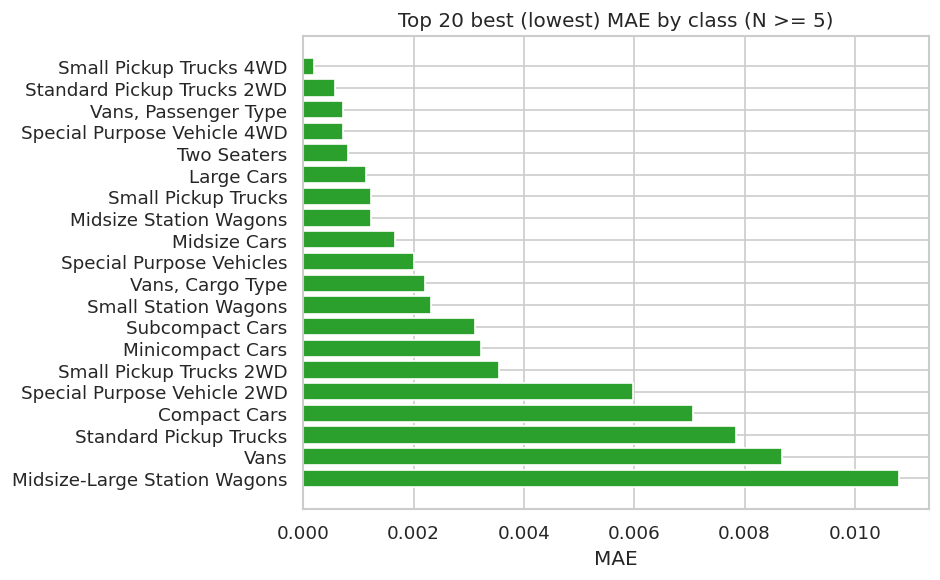

Saved plot: artifacts/group_errors_class_best_mae.png





In [50]:
sns.set(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

# CONFIG: adjust paths / groups / min_n as needed
HOLDOUT_CSV = 'artifacts/lgbm_no_leak_holdout_predictions.csv'   # must contain y_true, y_pred
WORK_CSV = 'artifacts/work_no_leak.csv'
OUT_PREFIX = 'artifacts/group_errors'
GROUPS = ['make', 'model', 'class']   # groups to evaluate
MIN_N = 5
TOP_SHOW = 40   # how many rows to display for tables
TOP_PLOT = 20   # how many groups to show in the bar plot

os.makedirs(os.path.dirname(OUT_PREFIX) or ".", exist_ok=True)

# helper
def compute_group_mae(hold_df, work_df, group_col, target_col='y_true', pred_col='y_pred', min_n=5):
    if group_col in work_df.columns:
        groups = work_df.loc[hold_df.index, group_col].fillna('MISSING')
    else:
        if group_col in hold_df.columns:
            groups = hold_df[group_col].fillna('MISSING')
        else:
            raise KeyError(f"Group column {group_col} not found in work or holdout")
    df = pd.DataFrame({'group': groups.values, 'y_true': hold_df[target_col].values, 'y_pred': hold_df[pred_col].values})
    stats = df.groupby('group').apply(lambda g: pd.Series({
        'MAE': (g['y_true'] - g['y_pred']).abs().mean(),
        'N': len(g)
    })).reset_index()
    stats = stats.sort_values('MAE', ascending=False)
    stats_filtered = stats[stats['N'] >= min_n].copy()
    return stats, stats_filtered

# Load data
hold = pd.read_csv(HOLDOUT_CSV)
work = pd.read_csv(WORK_CSV)

# Basic checks
if 'y_true' not in hold.columns or 'y_pred' not in hold.columns:
    raise KeyError("Holdout CSV must contain 'y_true' and 'y_pred' columns")

print(f"Holdout rows: {len(hold)}, Work rows: {len(work)}")
print("Groups to evaluate:", GROUPS)
print("Minimum group size for filtered view:", MIN_N)
print()

# For each group compute and display results inline
for g in GROUPS:
    print("="*80)
    print(f"Group: {g}")
    try:
        all_stats, stats_filtered = compute_group_mae(hold, work, g, min_n=MIN_N)
    except KeyError as e:
        print("ERROR:", e)
        continue

    # Save CSVs (same as script)
    csv_all = f"{OUT_PREFIX}_{g}_mae_all.csv"
    csv_filtered = f"{OUT_PREFIX}_{g}_mae_filtered.csv"
    all_stats.to_csv(csv_all, index=False)
    stats_filtered.to_csv(csv_filtered, index=False)
    print(f"Saved CSVs: {csv_all}, {csv_filtered}")

    # Show overall summary
    print("\nSummary stats (filtered groups, N>={})".format(MIN_N))
    print("Count of filtered groups:", len(stats_filtered))
    if len(stats_filtered) > 0:
        print("MAE (filtered) - mean: {:.4f}, median: {:.4f}, max: {:.4f}, min: {:.4f}".format(
            stats_filtered['MAE'].mean(), stats_filtered['MAE'].median(),
            stats_filtered['MAE'].max(), stats_filtered['MAE'].min()
        ))
    display(stats_filtered.head(TOP_SHOW))

    # Show worst MAE (top)
    worst = stats_filtered.sort_values('MAE', ascending=False).head(TOP_PLOT)
    if len(worst) > 0:
        plt.figure(figsize=(8, max(3, len(worst)*0.25)))
        plt.barh(worst['group'].astype(str), worst['MAE'], color='tab:orange')
        plt.xlabel('MAE')
        plt.title(f'Top {len(worst)} worst MAE by {g} (N >= {MIN_N})')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        png = f"{OUT_PREFIX}_{g}_top_mae.png"
        plt.savefig(png, dpi=150)
        plt.show()
        print("Saved plot:", png)
    else:
        print("No groups meet the min_n threshold for plotting.")

    # Also show best MAE groups (lowest error) to contrast
    best = stats_filtered.sort_values('MAE', ascending=True).head(TOP_PLOT)
    if len(best) > 0:
        plt.figure(figsize=(8, max(3, len(best)*0.25)))
        plt.barh(best['group'].astype(str), best['MAE'], color='tab:green')
        plt.xlabel('MAE')
        plt.title(f'Top {len(best)} best (lowest) MAE by {g} (N >= {MIN_N})')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        png2 = f"{OUT_PREFIX}_{g}_best_mae.png"
        plt.savefig(png2, dpi=150)
        plt.show()
        print("Saved plot:", png2)
    print("\n\n")